In [ ]:
%pip install scanpy mygene numba tqdm


In [ ]:
#All packages needed to run TwINFER simulation and inference are listed here.
#If any of them are not installed, please install them using pip or conda env.
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import numba
import tqdm
import scipy
import seaborn
import os
import sys
import joblib
import scanpy as sc
import os

import itertools
from itertools import product
from collections import defaultdict
from itertools import combinations

In [1]:
from google.colab import drive
drive.mount('/content/drive/')
data_path = "/content/drive/MyDrive/Goyal Lab/grn_inference_data_analysis/"


Mounted at /content/drive/


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1796: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


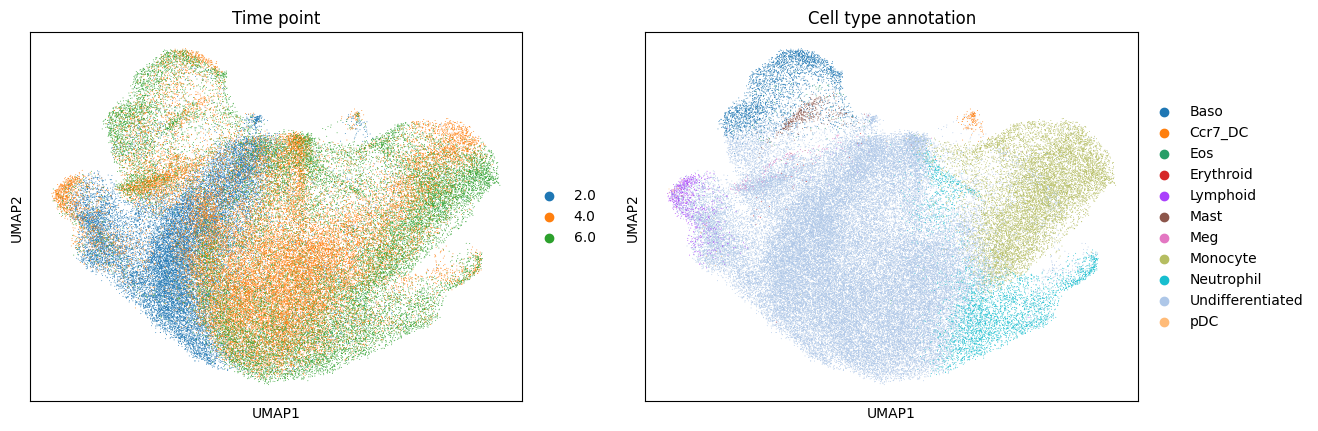

In [ ]:

# Define the full path to the data file
file_path = f'{data_path}LSK_d2_d4_d6.h5ad'

# Check if the file exists before attempting to load
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Error: The file '{file_path}' was not found. Please ensure the file is in the correct Google Drive location and that Google Drive is mounted correctly.")

# Load data
try:
    adata = sc.read_h5ad(file_path)
    adata.obs_names_make_unique()

    # Plot UMAP
    sc.pl.umap(adata, color=['Time point', 'Cell type annotation'])
except OSError as e:
    print(f"An OSError occurred: {e}")
    print("This might indicate that the file exists but is corrupted or not a valid H5AD file.")
    print(f"Please check the integrity of the file: {file_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


In [ ]:
from mygene import MyGeneInfo

# # Calculate cell cycle scores
cell_cycle_genes = [x.strip() for x in open(f'{data_path}/regev_lab_cell_cycle_genes.txt', encoding='utf-8-sig')]
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

mg = MyGeneInfo()
mouse_cell_cycle_genes = mg.querymany(cell_cycle_genes, scopes='symbol', fields='symbol', species='mouse')
mouse_cell_cycle_genes = [entry['symbol'] for entry in mouse_cell_cycle_genes if 'symbol' in entry]
mouse_s_genes = mg.querymany(s_genes, scopes='symbol', fields='symbol', species='mouse')
mouse_s_genes = [entry['symbol'] for entry in mouse_s_genes if 'symbol' in entry]
mouse_g2m_genes = mg.querymany(g2m_genes, scopes='symbol', fields='symbol', species='mouse')
mouse_g2m_genes = [entry['symbol'] for entry in mouse_g2m_genes if 'symbol' in entry]

mouse_cell_cycle_genes = [x for x in mouse_cell_cycle_genes if x in adata.var_names]
mouse_s_genes = [x for x in mouse_s_genes if x in adata.var_names]
mouse_g2m_genes = [x for x in mouse_g2m_genes if x in adata.var_names]
sc.tl.score_genes_cell_cycle(adata, s_genes=mouse_s_genes, g2m_genes=mouse_g2m_genes)

INFO:biothings.client:querying 1-97 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-43 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.
INFO:biothings.client:querying 1-54 ...
INFO:biothings.client:Finished.
INFO:biothings.client:Pass "returnall=True" to return complete lists of duplicate or missing query terms.


In [ ]:
from scipy.stats import mannwhitneyu

def compute_distances(adata):
    # assuming that the data is sorted by pair IDs
    pca = adata.obsm['X_pca']
    distances = pca[::2,:] - pca[1::2,:]
    distances = np.linalg.norm(distances, axis=1)
    return distances

def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

def add_stat_annotation(ax, category_a, category_b, label, subset, x0, level=0):
    """Draws a bracket and annotation between two y-categories."""
    # Get category positions (bottom to top)
    yticklabels = list(subset['pair_type'].drop_duplicates())  # categories actually present in the data, in order
    y1 = yticklabels.index(category_a)
    y2 = yticklabels.index(category_b)
    y_min, y_max = min(y1, y2), max(y1, y2)
    y_mid = (y1 + y2) / 2

    # Base offset
    x_offset = 0.5 + level * np.ceil(x0)/4  # spacing between bracket levels
    x = x0 + x_offset

    # Draw bracket
    ax.plot([x, x + 1, x + 1, x],
            [y_min, y_min, y_max, y_max],
            lw=1.5, color='black', clip_on=False)

    # Label at midpoint
    ax.text(x + 1.3, y_mid, label, va='center', ha='left', fontsize=12)

In [ ]:
#Identify if gene list is present in the dataset

#gene list from LARRY - neutrophil and
gene_list_Neutrophil = ['Muc13', 'Srgn', 'Ccl9', 'Plac8', 'Snrpf','Prtn3','Elane', 'Igfbp4', 'Ap3s1', 'Ctsg', 'Cd34'] #Neutrophil + Monocyte - fig 2 LARRY
gene_list_monocyte = ['Rbms1', 'Tuba1b','Sirpa', 'Ttf1', 'H3f3b', 'Set', 'Tk1', 'Fkbp4', 'Hspd1', 'Emb']
gene_list_ubi_exp = ['Sp1', 'Nfya', 'E2f1', 'Myc', 'Max', 'Nrf1', 'Tbp', 'Taf1', 'Atf4', 'Creb1', 'Usf1', 'Sp3', 'Klf4', 'Cebpb', 'Yy1'] #Ubiquitously expressed from 2011 paper
#replaced mll4 with gps2 and Gltscr1 not found
gene_list_perturb_seq = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']


In [ ]:
gene_list = list((gene_list_Neutrophil + gene_list_monocyte + gene_list_ubi_exp))

all_genes = {g.lower() for g in adata.var_names}
gene_list_check =  [g.lower() for g in gene_list]
found = [a for a in gene_list_check if a in all_genes]
print(f"Found {len(found)} genes out of {len(gene_list_check)}")
if found:
    print("✅ Found gene(s):", found)
else:
    print("❌ Not found in dataset")

gene_subset = [s + '_mRNA' for s in gene_list]

Found 36 genes out of 36
✅ Found gene(s): ['muc13', 'srgn', 'ccl9', 'plac8', 'snrpf', 'prtn3', 'elane', 'igfbp4', 'ap3s1', 'ctsg', 'cd34', 'rbms1', 'tuba1b', 'sirpa', 'ttf1', 'h3f3b', 'set', 'tk1', 'fkbp4', 'hspd1', 'emb', 'sp1', 'nfya', 'e2f1', 'myc', 'max', 'nrf1', 'tbp', 'taf1', 'atf4', 'creb1', 'usf1', 'sp3', 'klf4', 'cebpb', 'yy1']


In [ ]:
t1 = 2
t2 = 4
t3 = 6

In [ ]:
# # ########## NEW ##########

# # ### Create input file
# # Separate by time point

# adata_t1 = adata[(adata.obs['Time point'] == t1) & (adata.obs['clone_id'] != -1)].copy()
# adata_t2 = adata[(adata.obs['Time point'] == t2) & (adata.obs['clone_id'] != -1)].copy()
# adata_t3 = adata[(adata.obs['Time point'] == t3) & (adata.obs['clone_id'] != -1)].copy()

# # Pick subset of genes
# # gene_subset = [s + '_mRNA' for s in gene_list]

# # # Save cell IDs in .obs



# # ### Create tables for t1 and t2 twin pairs
# for adata_t, timepoint in zip([adata_t1,adata_t2,adata_t3], ['t1','t2', 't3']):
#     rows = []
#     for clone_id, group in adata_t.obs.groupby('clone_id'):
#         cells = group['cell_id'].tolist()
#         pair_counter = 0
#         for c1, c2 in itertools.combinations(cells, 2):
#             pair_id = f"{clone_id}_p{pair_counter}_{timepoint}"
#             rows.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': c1,
#                 'replicate': 1
#             })
#             rows.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': c2,
#                 'replicate': 2
#             })
#             pair_counter += 1

#     if timepoint == 't1':
#         t1_data = pd.DataFrame(rows)
#     elif timepoint == 't2':
#         t2_data = pd.DataFrame(rows)
#     else:
#         t3_data = pd.DataFrame(rows)

# t1_data['time_step'] = np.repeat(t1, len(t1_data))
# t2_data['time_step'] = np.repeat(t2, len(t2_data))
# t3_data['time_step'] = np.repeat(t3, len(t3_data))

# t1_data[gene_subset] = adata_t1[t1_data.cell_id, gene_list].X.toarray()
# t2_data[gene_subset] = adata_t2[t2_data.cell_id, gene_list].X.toarray()
# t3_data[gene_subset] = adata_t3[t3_data.cell_id, gene_list].X.toarray()

# # ### Create tables for across t twin pairs
# across_t_clones = list(set(adata_t1.obs.clone_id).intersection(adata_t2.obs.clone_id))
# adata_t1_sub = adata_t1[adata_t1.obs.clone_id.isin(across_t_clones)]
# adata_t2_sub = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]

# rows_t1 = []
# rows_t2 = []
# for clone_id in across_t_clones:
#     cells_t1 = adata_t1_sub[adata_t1_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
#     cells_t2 = adata_t2_sub[adata_t2_sub.obs.clone_id == clone_id].obs['cell_id'].tolist()
#     pair_counter = 0
#     for cell_t1 in cells_t1:
#         for cell_t2 in cells_t2:
#             pair_id = f"{clone_id}_p{pair_counter}_across_t"
#             rows_t1.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': cell_t1,
#                 'replicate': 1,
#                 'time_step': t1
#             })
#             rows_t2.append({
#                 'clone_id': clone_id,
#                 'pair_id': pair_id,
#                 'cell_id': cell_t2,
#                 'replicate': 2,
#                 'time_step': t2
#             })

#             pair_counter += 1

# across_t_data_t1 = pd.DataFrame(rows_t1)
# across_t_data_t2 = pd.DataFrame(rows_t2)

# across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1.cell_id, gene_list].X.toarray()
# across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2.cell_id, gene_list].X.toarray()
# across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])

########## OLD ##########

### Create input file
adata_t1 = adata[(adata.obs['Time point'] == t1) & (adata.obs['clone_id'] != -1)]
adata_t2 = adata[(adata.obs['Time point'] == t2) & (adata.obs['clone_id'] != -1)]
adata_t3 = adata[(adata.obs['Time point'] == t3) & (adata.obs['clone_id'] != -1)]

adata_t1.obs['cell_id'] = adata_t1.obs_names
adata_t2.obs['cell_id'] = adata_t2.obs_names
adata_t3.obs['cell_id'] = adata_t3.obs_names

# Pick subset of genes
# gene_list = ['Muc13', 'Srgn', 'Ccl9', 'Elane', 'Igfbp4', 'Rbms1', 'Sirpa', 'Set', 'Tk1', 'Spp1']
# gene_list = ['Pou5f1', 'Sox2', 'Nanog', 'Klf4', 'Myc', 'Zfp42', 'Zfp281']
# gene_list = ['Brd9', 'Gata1', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']
gene_subset = [s + '_mRNA' for s in gene_list]

# Find across t clones
across_t_clones = np.array(list(set(adata_t1.obs.clone_id.value_counts().index[adata_t1.obs.clone_id.value_counts() == 1]).intersection(adata_t2.obs.clone_id.unique())))

# From each clone, randomly pick a differentiated cell
t1_across_t_clones_cells = {}
t2_across_t_clones_cells = {}
adata_t2_across = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]
for clone in across_t_clones:
    t1_across_t_clones_cells[clone] = adata_t1[adata_t1.obs.clone_id == clone].obs_names[0]
    idx = adata_t2_across[adata_t2_across.obs.clone_id == clone].obs_names
    t2_across_t_clones_cells[clone] = np.random.choice(idx, size=1)[0]

# create csv file
across_t_data_t1 = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
across_t_data_t1['cell_id'] = list(t1_across_t_clones_cells.values())
across_t_data_t1['clone_id'] = list(t1_across_t_clones_cells.keys())
across_t_data_t1['time_step'] = np.repeat(t1, len(across_t_data_t1))
across_t_data_t1['replicate'] = np.repeat(1, len(across_t_data_t1))
across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1['cell_id'], gene_list].X.toarray()

across_t_data_t2 = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
across_t_data_t2['cell_id'] = list(t2_across_t_clones_cells.values())
across_t_data_t2['clone_id'] = list(t2_across_t_clones_cells.keys())
across_t_data_t2['time_step'] = np.repeat(t2, len(across_t_data_t2))
across_t_data_t2['replicate'] = np.repeat(2, len(across_t_data_t2))
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2['cell_id'], gene_list].X.toarray()

across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])
# across_t_data.to_csv('LARRY_across_t_twins.csv')

# Excluding across t clones, pick all two-cell clones from t1
temp = adata_t1[~adata_t1.obs.clone_id.isin(across_t_clones)].obs.clone_id.value_counts()
t1_clones = np.array(list(temp.index[temp == 2]))

# create csv file
t1_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
t1_data['cell_id'] = adata_t1[adata_t1.obs.clone_id.isin(t1_clones)].obs_names
t1_data['clone_id'] = adata_t1[adata_t1.obs.clone_id.isin(t1_clones)].obs['clone_id'].values
t1_data['time_step'] = np.repeat(t1, len(t1_data))
t1_data['replicate'] = t1_data.groupby("clone_id").cumcount() + 1
t1_data[gene_subset] = adata_t1[t1_data['cell_id'], gene_list].X.toarray()
# t1_data.to_csv('/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis_new/LARRY_t1_twins.csv')

# Excluding across t clones, find clones with 2 cells
temp = adata_t2[(~adata_t2.obs.clone_id.isin(across_t_clones)) & (~adata_t2.obs.clone_id.isin(t1_clones))].obs.clone_id.value_counts()
# t2_clones = np.array(list(temp.index[temp == 2]))
t2_clones = np.array(list(temp.index[temp != 1]))

# From each of these clones, randomly pick two cells
adata_t2_within = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)]
t2_within_clones_cells = {}
for clone in t2_clones:
    idx = adata_t2_within[adata_t2_within.obs.clone_id == clone].obs_names
    t2_within_clones_cells[clone] = list(np.random.choice(idx, size=2))

t2_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
# t2_data['cell_id'] = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)].obs_names
# t2_data['clone_id'] = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)].obs['clone_id'].values
t2_data['cell_id'] = np.array(list(t2_within_clones_cells.values())).reshape(-1)
t2_data['clone_id'] = np.repeat(np.array(list(t2_within_clones_cells.keys())), 2)
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t2_data['replicate'] = t2_data.groupby("clone_id").cumcount() + 1
t2_data[gene_subset] = adata_t2[t2_data['cell_id'], gene_list].X.toarray()
# t2_data.to_csv('/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis_new/LARRY_t2_twins.csv')

# Subsample if t1_data << t2_data
if int(t1_data.shape[0]/2)*1.5 <= int(t2_data.shape[0]/2):
    t2_clones = t2_data.clone_id.unique()
    np.random.seed(42)
    t2_clones_sub = np.random.choice(t2_clones, size=int(t1_data.shape[0]/2), replace=False)
    t2_data = t2_data[t2_data.clone_id.isin(t2_clones_sub)]

temp = adata_t3.obs.clone_id.value_counts()
t3_clones = np.array(list(temp.index[temp == 2]))

# create csv file
t3_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
t3_data['cell_id'] = adata_t3[adata_t3.obs.clone_id.isin(t3_clones)].obs_names
t3_data['clone_id'] = adata_t3[adata_t3.obs.clone_id.isin(t3_clones)].obs['clone_id'].values
t3_data['time_step'] = np.repeat(t3, len(t3_data))
t3_data['replicate'] = t3_data.groupby("clone_id").cumcount() + 1
t3_data[gene_subset] = adata_t3[t3_data['cell_id'], gene_list].X.toarray()
# t3_data.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis_new/LARRY_t3_twins.csv")
# t1_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_t1_twins.csv', index_col=0, sep=',')
# t2_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_t2_twins.csv', index_col=0, sep=',')
# across_t_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_across_t_twins.csv', index_col=0, sep=',')

twin_data = pd.concat([t1_data, t2_data, across_t_data])
# twin_data.to_csv('LARRY_twins.csv')

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data.shape[0]/2)}")

# ### Print number of twin pairs
print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data_t1.shape[0])}")

/tmp/ipython-input-3194586287.py:99: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_t1.obs['cell_id'] = adata_t1.obs_names
/tmp/ipython-input-3194586287.py:100: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_t2.obs['cell_id'] = adata_t2.obs_names
/tmp/ipython-input-3194586287.py:101: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_t3.obs['cell_id'] = adata_t3.obs_names


Number of t1 twins: 621
Number of t2 twins: 621
Number of t3 twins: 476
Number of across t twins: 593
Number of t1 twins: 621
Number of t2 twins: 621
Number of t3 twins: 476
Number of across t twins: 593


In [ ]:
# Compute distances in PC space
distances_t1 = compute_distances(adata_t1[t1_data.cell_id])
distances_t2 = compute_distances(adata_t2[t2_data.cell_id])
distances_t3 = compute_distances(adata_t3[t3_data.cell_id])

distances_across_t = adata_t1[across_t_data_t1.cell_id].obsm['X_pca'] - adata_t2[across_t_data_t2.cell_id].obsm['X_pca']
distances_across_t = np.linalg.norm(distances_across_t, axis=1)

# Cell cycle synchronization
in_sync_t1 = adata_t1[t1_data.cell_id].obs['phase'][::2].values == adata_t1[t1_data.cell_id].obs['phase'][1::2].values
in_sync_t2 = adata_t2[t2_data.cell_id].obs['phase'][::2].values == adata_t2[t2_data.cell_id].obs['phase'][1::2].values
in_sync_t3 = adata_t3[t3_data.cell_id].obs['phase'][::2].values == adata_t3[t3_data.cell_id].obs['phase'][1::2].values

# Random
np.random.seed(42)
t1_cell_ids = adata_t1.obs['cell_id'].values.tolist()
randomly_drawn_cell_ids = np.random.choice(t1_cell_ids, size=t1_data.shape[0], replace=True)
distances_random_t1 = adata_t1[randomly_drawn_cell_ids[::2]].obsm['X_pca'] - adata_t1[randomly_drawn_cell_ids[1::2]].obsm['X_pca']
distances_random_t1 = np.linalg.norm(distances_random_t1, axis=1)
in_sync_random_t1 = adata_t1[randomly_drawn_cell_ids[::2]].obs['phase'].values == adata_t1[randomly_drawn_cell_ids[1::2]].obs['phase'].values

t2_cell_ids = adata_t2.obs['cell_id'].values.tolist()
randomly_drawn_cell_ids = np.random.choice(t2_cell_ids, size=t2_data.shape[0], replace=True)
distances_random_t2 = adata_t2[randomly_drawn_cell_ids[::2]].obsm['X_pca'] - adata_t2[randomly_drawn_cell_ids[1::2]].obsm['X_pca']
distances_random_t2 = np.linalg.norm(distances_random_t2, axis=1)
in_sync_random_t2 = adata_t2[randomly_drawn_cell_ids[::2]].obs['phase'].values == adata_t2[randomly_drawn_cell_ids[1::2]].obs['phase'].values

t3_cell_ids = adata_t3.obs['cell_id'].values.tolist()
randomly_drawn_cell_ids = np.random.choice(t3_cell_ids, size=t3_data.shape[0], replace=True)
distances_random_t3 = adata_t3[randomly_drawn_cell_ids[::2]].obsm['X_pca'] - adata_t3[randomly_drawn_cell_ids[1::2]].obsm['X_pca']
distances_random_t3 = np.linalg.norm(distances_random_t3, axis=1)
in_sync_random_t3 = adata_t3[randomly_drawn_cell_ids[::2]].obs['phase'].values == adata_t3[randomly_drawn_cell_ids[1::2]].obs['phase'].values

randomly_drawn_cell_ids_t1 = np.random.choice(t1_cell_ids, size=across_t_data_t1.shape[0], replace=True)
randomly_drawn_cell_ids_t2 = np.random.choice(t2_cell_ids, size=across_t_data_t2.shape[0], replace=True)
distances_random_across_t = adata_t1[randomly_drawn_cell_ids_t1].obsm['X_pca'] - adata_t2[randomly_drawn_cell_ids_t2].obsm['X_pca']
distances_random_across_t = np.linalg.norm(distances_random_across_t, axis=1)

# Create dataframe for plotting
df_distances = pd.DataFrame({
    'Transcriptomic distance [a.u.]': np.concatenate([distances_t1, distances_t2, distances_t3, distances_across_t,
                                distances_random_t1, distances_random_t2, distances_random_t3, distances_random_across_t]),
    'pair_type': (['Clonal pairs'] * len(distances_t1) +
                  ['Clonal pairs'] * len(distances_t2) +
                  ['Clonal pairs'] * len(distances_t3) +
                  ['Clonal pairs'] * len(distances_across_t) +
                  ['Random pairs'] * len(distances_random_t1) +
                  ['Random pairs'] * len(distances_random_t2) +
                  ['Random pairs'] * len(distances_random_t3) +
                  ['Random pairs'] * len(distances_random_across_t)),
    'in_sync': np.concatenate([in_sync_t1, in_sync_t2, in_sync_t3, np.array([np.nan]*len(distances_across_t)),
                               in_sync_random_t1, in_sync_random_t2, in_sync_random_t3, np.array([np.nan]*len(distances_random_across_t))]),
    'timepoint': (['Day 2'] * len(distances_t1) +
                  ['Day 4'] * len(distances_t2) +
                  ['Day 6'] * len(distances_t3) +
                  ['Across T'] * len(distances_across_t) +
                  ['Day 2'] * len(distances_random_t1) +
                  ['Day 4'] * len(distances_random_t2) +
                  ['Day 6'] * len(distances_random_t3) +
                  ['Across T'] * len(distances_random_across_t))
})

In [ ]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
# font_paths = [
#     "/home/gzu5140/Font/Arial.ttf",
#     "/home/gzu5140/Font/Arial Bold.ttf",
#     "/home/gzu5140/Font/Arial Italic.ttf",
#     "/home/gzu5140/Font/Arial Bold Italic.ttf",
# ]

# for fp in font_paths:
#     try:
#         fm.fontManager.addfont(fp)
#         print("✔ Loaded font:", fp)
#     except Exception as e:
#         print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
# plt.rcParams['font.sans-serif'] = ["Arial"]
# plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
# plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18*1.5      # x/y labels
plt.rcParams['axes.titlesize'] = 20*1.5
plt.rcParams['xtick.labelsize'] = 12*1.5     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12*1.5    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12*1.5     # legend text

/tmp/ipython-input-3521961662.py:139: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(rect=[0, 0, 1, 0.90])


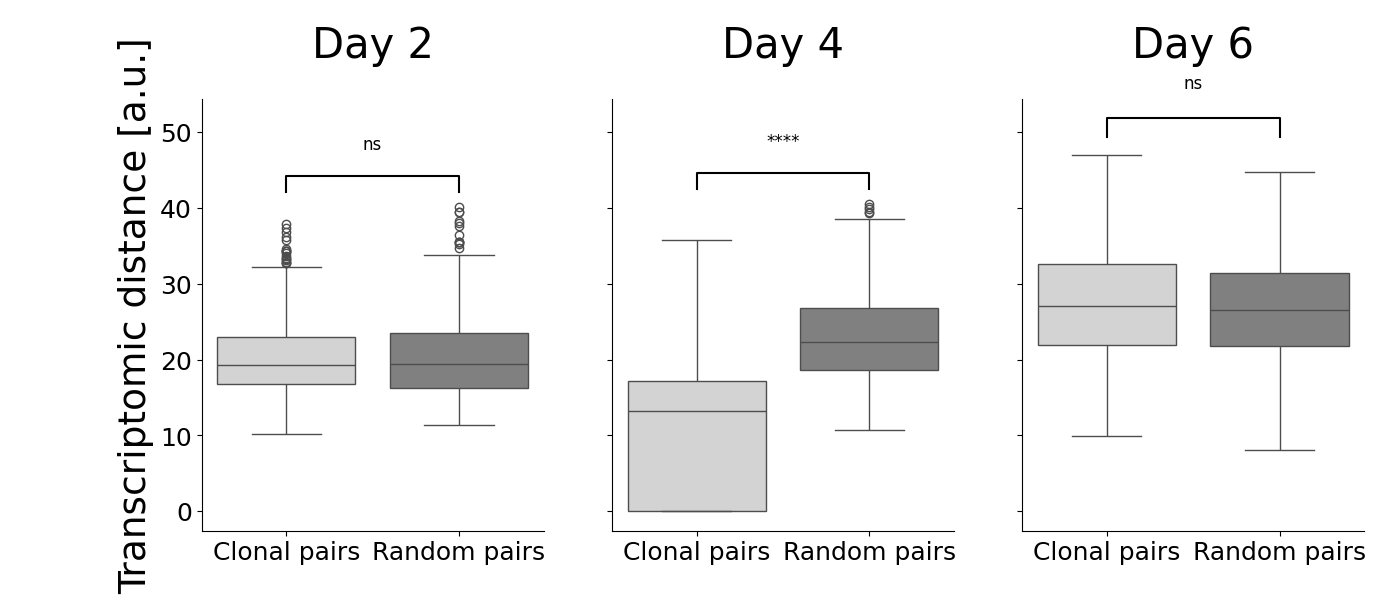

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ============================
#   1. Distance computation
# ============================
def compute_distances(adata):
    """
    Compute pairwise transcriptomic distances assuming cells are sorted
    in twin order: (cell0_A, cell0_B, cell1_A, cell1_B, ...)
    """
    pca = adata.obsm['X_pca']
    distances = pca[::2, :] - pca[1::2, :]
    return np.linalg.norm(distances, axis=1)


# ============================
#   2. Significance symbols
# ============================
def get_significance_symbol(pval):
    if pval > 0.05:
        return 'ns'
    elif pval <= 0.0001:
        return '****'
    elif pval <= 0.001:
        return '***'
    elif pval <= 0.01:
        return '**'
    else:
        return '*'

# ============================
#   3. Stat annotation for VERTICAL boxplots
# ============================
def add_stat_annotation(ax, category_a, category_b, label, subset,
                        y_offset=0.05, level=0):
    """
    Draws a significance bracket ABOVE vertical boxplots with clip turned OFF.
    """

    # X-axis category names
    xticklabels = [tick.get_text() for tick in ax.get_xticklabels()]

    if category_a not in xticklabels or category_b not in xticklabels:
        return

    x1 = xticklabels.index(category_a)
    x2 = xticklabels.index(category_b)
    x_min, x_max = min(x1, x2), max(x1, x2)

    # Height for bracket
    ymax = subset['Transcriptomic distance [a.u.]'].max()
    h = ymax * (1 + y_offset + level * 0.12)

    # Bracket line (no clipping)
    ax.plot(
        [x_min, x_min, x_max, x_max],
        [h, h * 1.05, h * 1.05, h],
        lw=1.5,
        color='black',
        clip_on=False
    )

    # Label (no clipping)
    ax.text(
        (x_min + x_max) / 2,
        h * 1.12,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        clip_on=False
    )

# ============================
#   4. Plot vertical boxplots
# ============================
def plot_vertical_boxplots(df_distances, save_dir = None):

    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(top=0.83)  # Ensure title + brackets never clip

    timepoints = ['Day 2', 'Day 4', 'Day 6']

    for ax, timepoint in zip(axes, timepoints):

        subset = df_distances[df_distances['timepoint'] == timepoint]

        # -----------------------------
        # Vertical boxplot
        # -----------------------------
        bp = sns.boxplot(
            data=subset,
            x='pair_type',
            y='Transcriptomic distance [a.u.]',
            hue='pair_type',
            palette={'Clonal pairs': 'lightgray', 'Random pairs': 'gray'},
            ax=ax
        )

        # Disable clipping for every boxplot artist
        for artist in ax.artists + ax.lines:
            artist.set_clip_on(False)

        sns.despine(right=True, top=True, ax=ax)

        ax.set_xlabel('')
        ax.set_ylabel('Transcriptomic distance [a.u.]')
        ax.set_title(timepoint, pad=30)  # higher title

        # -----------------------------
        # Mann-Whitney U-test
        # -----------------------------
        clonal = subset[subset['pair_type'] == 'Clonal pairs']['Transcriptomic distance [a.u.]']
        random = subset[subset['pair_type'] == 'Random pairs']['Transcriptomic distance [a.u.]']

        _, pval = mannwhitneyu(clonal, random, alternative='two-sided')
        label = get_significance_symbol(pval)

        # -----------------------------
        # Add significance bracket
        # -----------------------------
        add_stat_annotation(
            ax=ax,
            category_a='Clonal pairs',
            category_b='Random pairs',
            label=label,
            subset=subset,
            y_offset=0.05,
            level=0
        )

    # Legend outside (no clipping)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    if save_dir:
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist.svg'),
                    format='svg',
                    facecolor='none', edgecolor='none', transparent=True)
        plt.savefig(os.path.join(save_dir, 'twin_random_PCA_dist.pdf'),
                    format='pdf',
                    facecolor='none', edgecolor='none', transparent=True)

# ============================
#   5. Run
# ============================
path_to_plots = f"{data_path}/plots/"
os.makedirs(path_to_plots, exist_ok=True)
plot_vertical_boxplots(df_distances, save_dir = None)

In [ ]:
adata_t1_clones = adata[(adata.obs['Time point'] == 2.0) & (adata.obs['clone_id'] != -1)]
adata_t2_clones = adata[(adata.obs['Time point'] == 4.0) & (adata.obs['clone_id'] != -1)]
adata_t3_clones = adata[(adata.obs['Time point'] == 6.0) & (adata.obs['clone_id'] != -1)]


In [ ]:
adata_t1_clones_new = adata[(adata.obs['Time point'] == 2.0) & (adata.obs['clone_id'] != -1) & (adata.obs['Cell type annotation'] == 'Undifferentiated')]
print(adata_t1_clones_new.shape, adata_t1_clones.shape)

(2770, 25289) (2809, 25289)


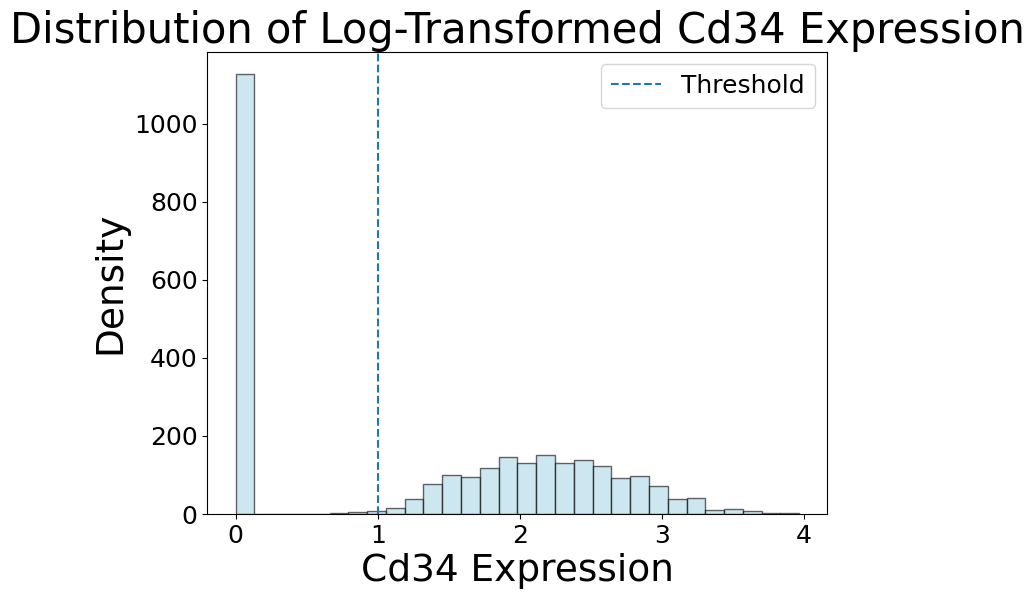

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import numpy as np

# Get Cd34 expression and ensure it's in a proper format
cd34_expression = adata_t1_clones_undiff[:, 'Cd34'].X.toarray().flatten()

# Plot the histogram of log-transformed Cd34 expression
plt.figure(figsize=(8, 6))
plt.hist(cd34_expression, bins=30, color='lightblue', edgecolor='black', alpha=0.6, density=False)
plt.axvline(x=1, linestyle = "--", label = "Threshold")
plt.title('Distribution of Log-Transformed Cd34 Expression')
plt.xlabel('Cd34 Expression')
plt.legend()
plt.ylabel('Density')
plt.show()



In [ ]:
import numpy as np
import pandas as pd

# Set threshold for defining "undifferentiated" cells
threshold = 1  # Example threshold for Cd34 expression

# Identify cells that are undifferentiated and have CD34 greater than threshold
adata_t1_clones_undiff = adata_t1[adata_t1.obs['Cell type annotation'] == 'Undifferentiated']
cd34_expression = adata_t1_clones_undiff[:, 'Cd34'].X.toarray().flatten()
adata_t1_undiff_high_CD34 = adata_t1_clones_undiff[cd34_expression > threshold]

# Print the results
print(f"Number of cells: {adata_t1.shape[0]}")
print(f"Number of undifferentiated labeled cells: {adata_t1_clones_undiff.shape[0]}")
print(f"Number of undifferentiated labeled cells with high CD34: {adata_t1_undiff_high_CD34.shape[0]}")


Number of cells: 2809
Number of undifferentiated labeled cells: 2770
Number of undifferentiated labeled cells with high CD34: 1634


In [ ]:
import pandas as pd

# Initialize dictionary to store cell type counts and percentages for each clone_id
clone_cell_type = {}

# Loop through each unique clone_id
for clone_id in adata_t1_undiff_high_CD34.obs.clone_id.unique():
    # Get unique cell types for t2 and t3 as lists
    unique_t2_cell_types = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()
    unique_t3_cell_types = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].unique().tolist()

    # Concatenate the lists and convert to a set (to avoid duplicates)
    cell_type = set(unique_t2_cell_types + unique_t3_cell_types)
    if len(cell_type) < 1:
        continue

    # Get the number of cells for each cell type at t2 and t3
    t2_cell_counts = adata_t2[adata_t2.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()
    t3_cell_counts = adata_t3[adata_t3.obs.clone_id == clone_id].obs['Cell type annotation'].value_counts()

    # Initialize dictionary to store counts and percentages
    cell_type_info = {}

    # Count and calculate percentages for t2
    total_cells_t2 = len(adata_t2[adata_t2.obs.clone_id == clone_id])
    for cell in cell_type:
        t2_count = t2_cell_counts.get(cell, 0)
        t2_percentage = (t2_count / total_cells_t2) * 100 if total_cells_t2 > 0 else 0
        cell_type_info[cell] = {'t2_count': t2_count, 't2_percentage': t2_percentage}

    # Count and calculate percentages for t3
    total_cells_t3 = len(adata_t3[adata_t3.obs.clone_id == clone_id])
    for cell in cell_type:
        t3_count = t3_cell_counts.get(cell, 0)
        t3_percentage = (t3_count / total_cells_t3) * 100 if total_cells_t3 > 0 else 0
        if cell in cell_type_info:
            cell_type_info[cell].update({'t3_count': t3_count, 't3_percentage': t3_percentage})
        else:
            cell_type_info[cell] = {'t3_count': t3_count, 't3_percentage': t3_percentage}

    # Store the information in the dictionary
    clone_cell_type[clone_id] = cell_type_info

# Convert the dictionary into a pandas DataFrame for easier inspection
cell_type_df = pd.DataFrame.from_dict({(clone_id, cell_type): values
                                       for clone_id, clone_info in clone_cell_type.items()
                                       for cell_type, values in clone_info.items()},
                                      orient='index')

# Display the DataFrame
print(cell_type_df)


                       t2_count  t2_percentage  t3_count  t3_percentage
5827 Monocyte                 1          100.0         0       0.000000
216  Eos                      1          100.0         0       0.000000
4676 Undifferentiated         2          100.0         1     100.000000
5412 Undifferentiated         1          100.0         0       0.000000
2703 Undifferentiated         3          100.0         0       0.000000
...                         ...            ...       ...            ...
1350 Lymphoid                 0            0.0         1      12.500000
4754 Lymphoid                 1          100.0         0       0.000000
3065 Undifferentiated         2          100.0         2     100.000000
5490 Undifferentiated         6          100.0         7      19.444444
     Monocyte                 0            0.0        29      80.555556

[1154 rows x 4 columns]


In [ ]:
import pandas as pd

# Assuming clone_cell_type is already populated as shown in the previous code

# Initialize a dictionary to store the dominant cell type(s) for each clone_id
clone_dominant_cell_type = {}

# Loop through each clone_id and determine the dominant cell type(s) at t2 and t3
for clone_id, cell_type_info in clone_cell_type.items():
    # Initialize a list to store dominant cell types for this clone
    dominant_cell_types = []

    # Find the dominant cell type based on the highest percentage in t2
    max_t2_percentage = max(cell_info['t2_percentage'] for cell_info in cell_type_info.values())
    dominant_cell_types_t2 = [cell_type for cell_type, cell_info in cell_type_info.items() if cell_info['t2_percentage'] == max_t2_percentage]

    # Add the dominant cell types at t2 to the list

    # Find the dominant cell type based on the highest percentage in t3
    max_t3_percentage = max(cell_info['t3_percentage'] for cell_info in cell_type_info.values())
    dominant_cell_types_t3 = [cell_type for cell_type, cell_info in cell_type_info.items() if cell_info['t3_percentage'] == max_t3_percentage]

    # Add the dominant cell types at t3 to the list
    if max_t2_percentage > max_t3_percentage:
      dominant_cell_types.extend(dominant_cell_types_t2)
    else:
      dominant_cell_types.extend(dominant_cell_types_t3)

    # Store the dominant cell types for the current clone
    clone_dominant_cell_type[clone_id] = dominant_cell_types

# Now, assign the dominant cell type(s) to each clone in adata.obs
adata_t1_undiff_high_CD34.obs['dominant_cell_type'] = None
# Loop through each clone_id and assign the dominant cell type(s) to adata.obs
for clone_id, dominant_cell_types in clone_dominant_cell_type.items():
    # Join the dominant cell types into a string (e.g., "CellA, CellB")
    dominant_cell_types_str = dominant_cell_types[0]

    # Annotate the clone in adata.obs
    adata_t1_undiff_high_CD34.obs.loc[adata_t1_undiff_high_CD34.obs.clone_id == clone_id, 'dominant_cell_type'] = dominant_cell_types_str

# Optionally, view the annotated data to ensure the clones are properly annotated
print(adata_t1_undiff_high_CD34.obs[['clone_id', 'dominant_cell_type']].drop_duplicates())


                     clone_id dominant_cell_type
Cell barcode                                    
TCGCAATC-GAGAGTAT        4187               None
AAACGATC-CCTACTAG        1898               None
AACTCAGT-GGCGTTAG        3410               None
AGGCAATA-CTTCGATT        5827           Monocyte
AAACACGG-GCACCTCT        2740               None
...                       ...                ...
AAATTCCG-TGACCCTC-1      4498               None
TAGCGGAT-ACGCTCAG        1350   Undifferentiated
CATTTCTA-AGCGTAGG        4754           Lymphoid
TCCGCTGT-CATACATT        3065   Undifferentiated
AGGTAAGC-GTCCGTAC-1      5490   Undifferentiated

[1180 rows x 2 columns]


In [ ]:
# Get the unique cell types in the 'dominant_cell_type' column
cell_type_list = adata_t1_undiff_high_CD34.obs['dominant_cell_type'].unique()

# Print the total number of cells
print(f"Number of cells: {adata_t1_undiff_high_CD34.shape[0]}")

# Print the number of cell types and list them
print(f"Number of cell types: {len(cell_type_list)}")
print(f"Cell types: {cell_type_list}")

# Count the number of cells in each cell type
cell_type_counts = adata_t1_undiff_high_CD34.obs['dominant_cell_type'].value_counts()

# Print the number of cells for each cell type
for cell_type, count in cell_type_counts.items():
    print(f"{cell_type}: {count}")


Number of cells: 1634
Number of cell types: 10
Cell types: [None 'Monocyte' 'Eos' 'Undifferentiated' 'Neutrophil' 'Lymphoid' 'Meg'
 'Baso' 'Ccr7_DC' 'Mast']
Undifferentiated: 514
Monocyte: 199
Neutrophil: 116
Baso: 48
Lymphoid: 27
Eos: 3
Meg: 3
Ccr7_DC: 2
Mast: 2


In [ ]:
gene_list

['Yy1',
 'Emb',
 'Nrf1',
 'Prtn3',
 'Nfya',
 'Elane',
 'Srgn',
 'Tuba1b',
 'H3f3b',
 'Max',
 'Muc13',
 'Rbms1',
 'Tk1',
 'Tbp',
 'Sirpa',
 'Ap3s1',
 'Taf1',
 'Set',
 'Fkbp4',
 'E2f1',
 'Usf1',
 'Ccl9',
 'Ttf1',
 'Myc',
 'Snrpf',
 'Sp1',
 'Sp3',
 'Hspd1',
 'Igfbp4',
 'Creb1',
 'Cd34',
 'Cebpb',
 'Plac8',
 'Atf4',
 'Klf4',
 'Ctsg']

In [ ]:
!pip install adjustText
from adjustText import adjust_text  # Import adjustText library


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3039107364.py:94: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = mannwhitneyu(expr_group1, expr_group2, alternative='two-sided')
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3039107364.py:94: SmallSampleWarning: One or more sample arguments is too small; al

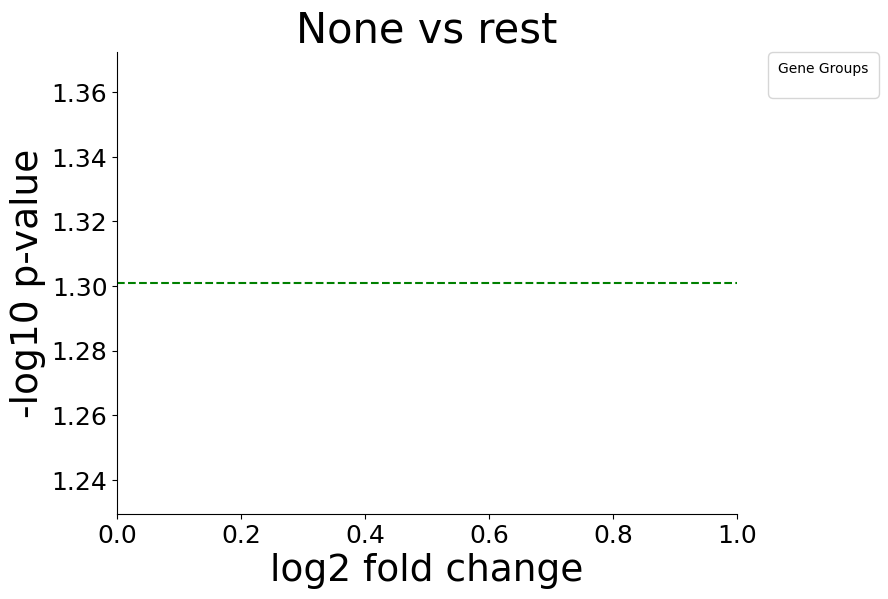

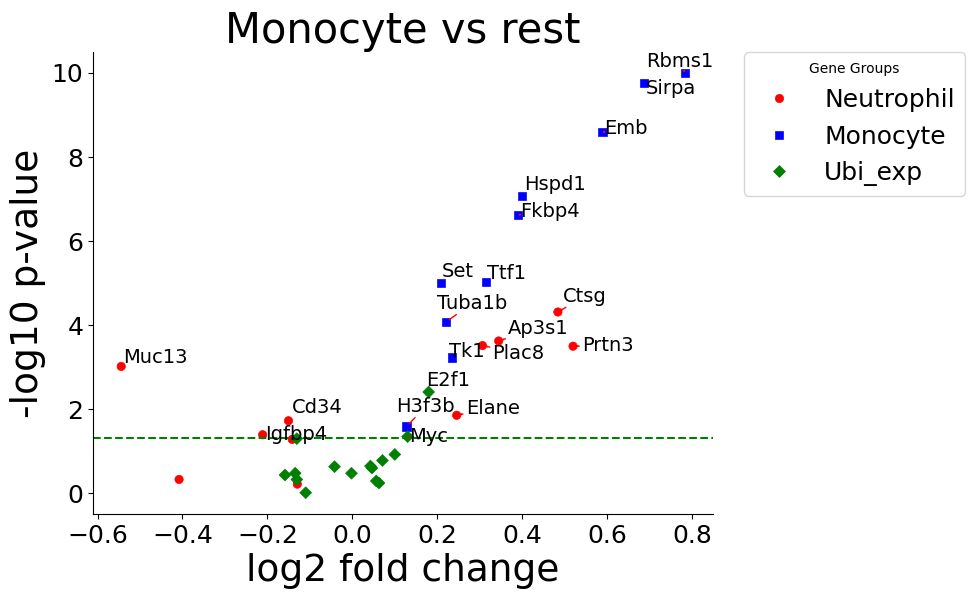

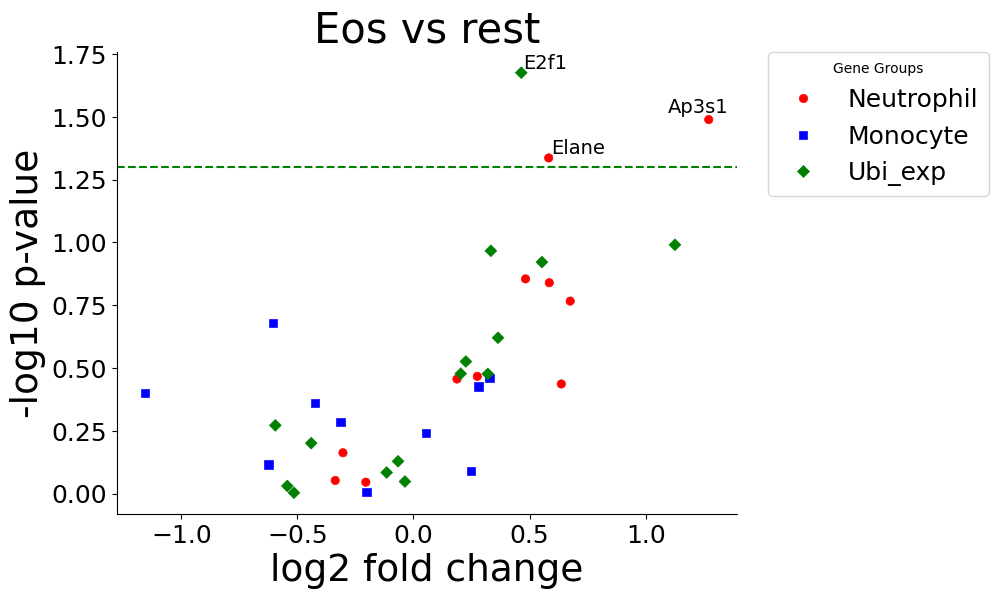

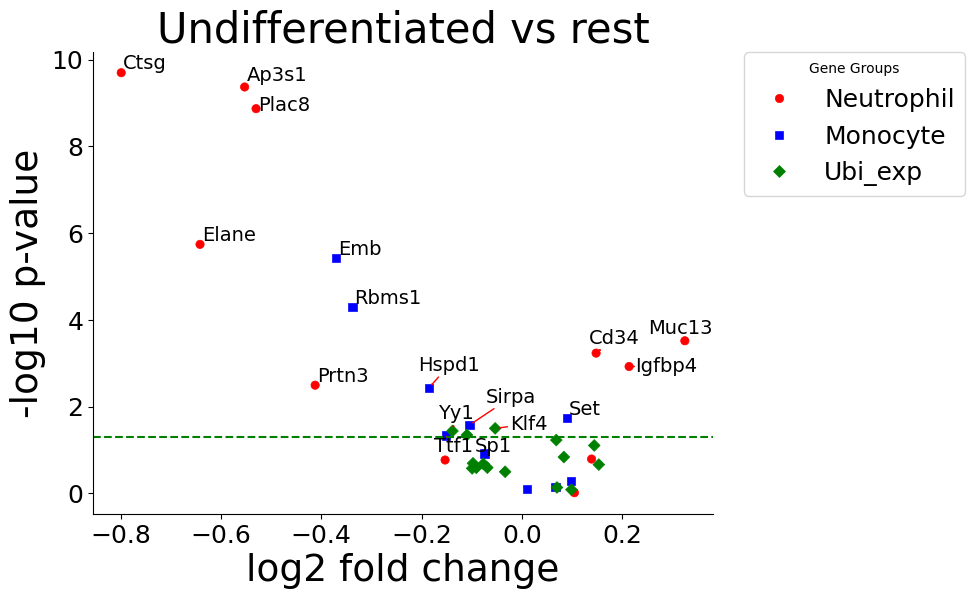

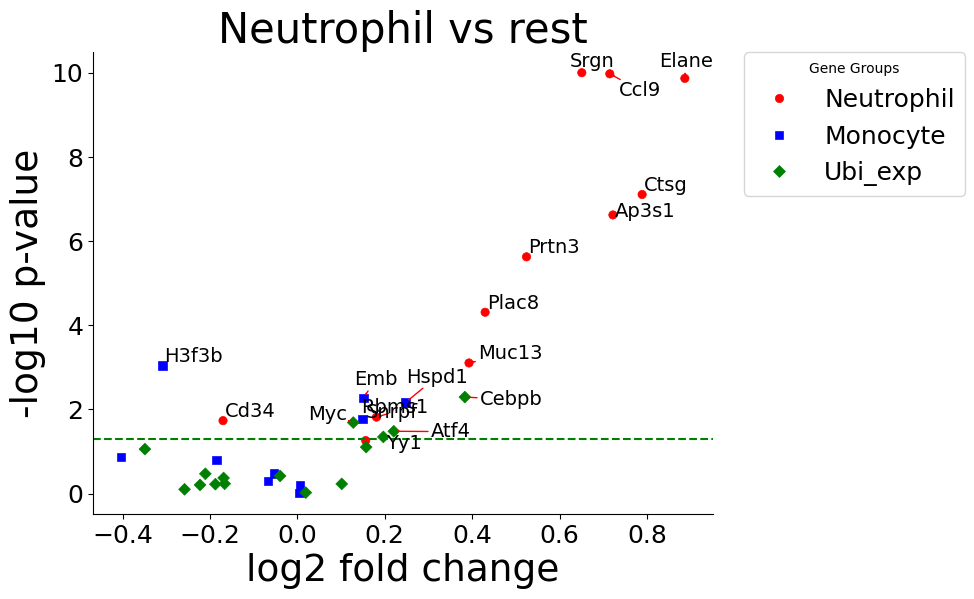

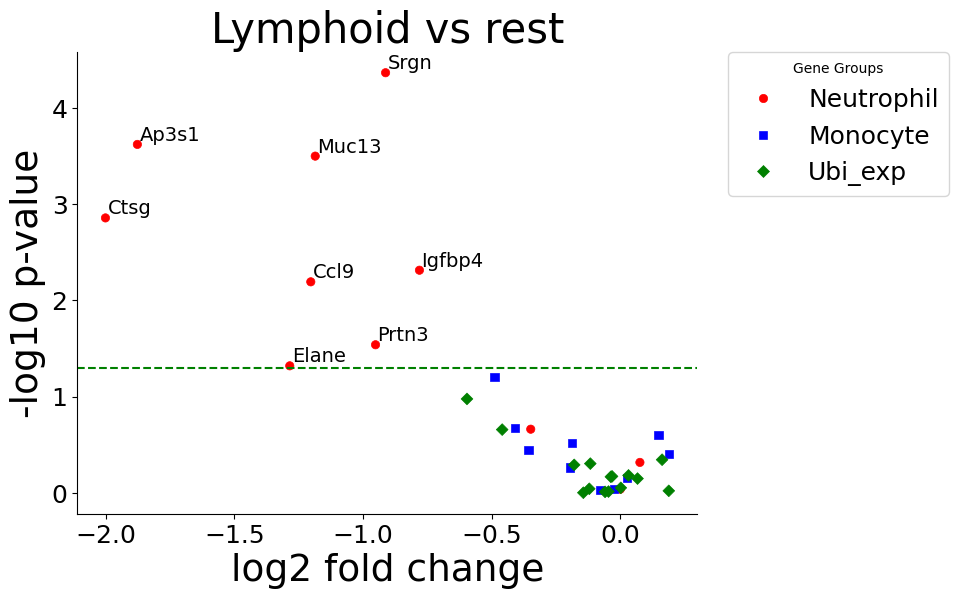

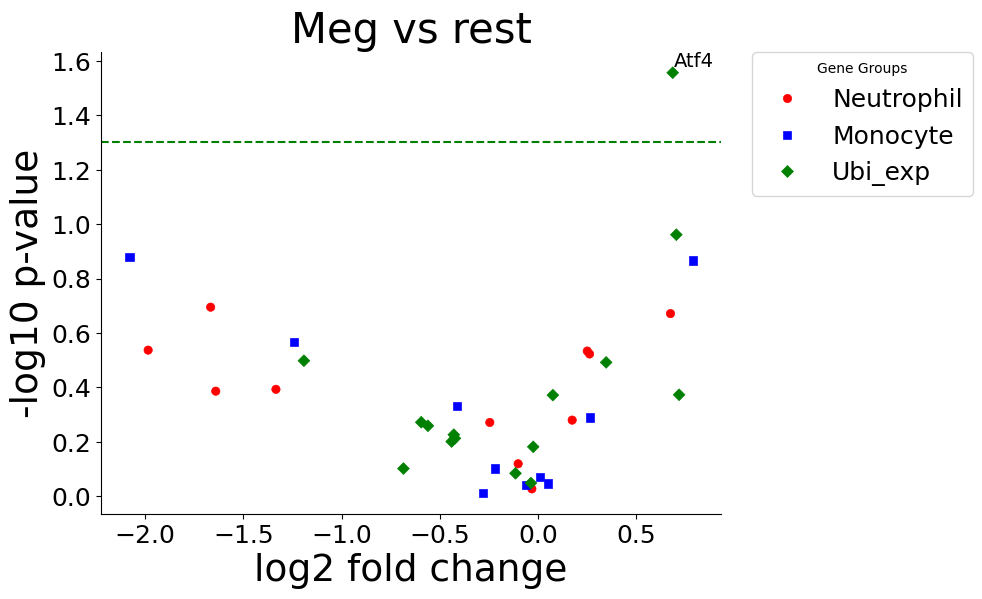

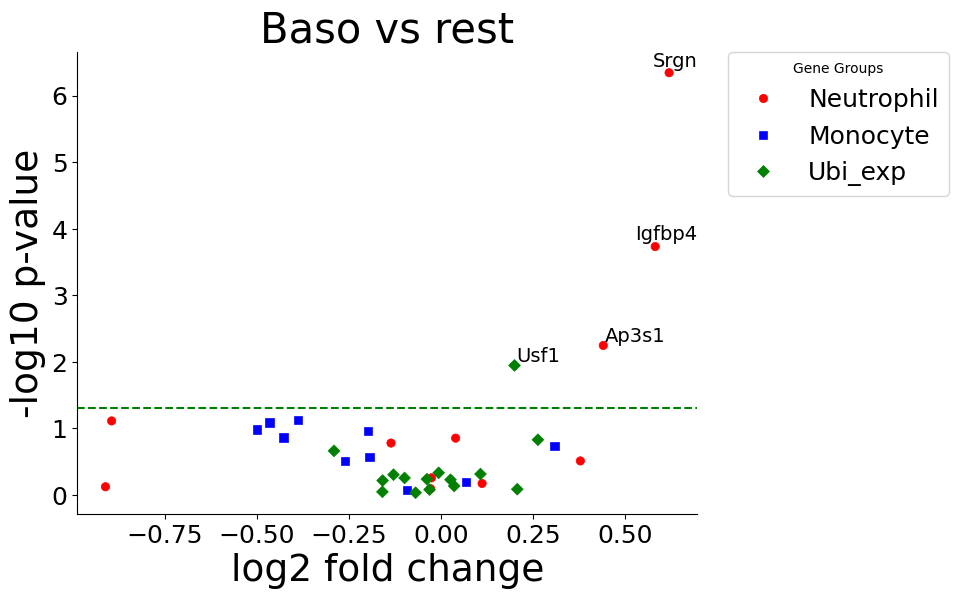

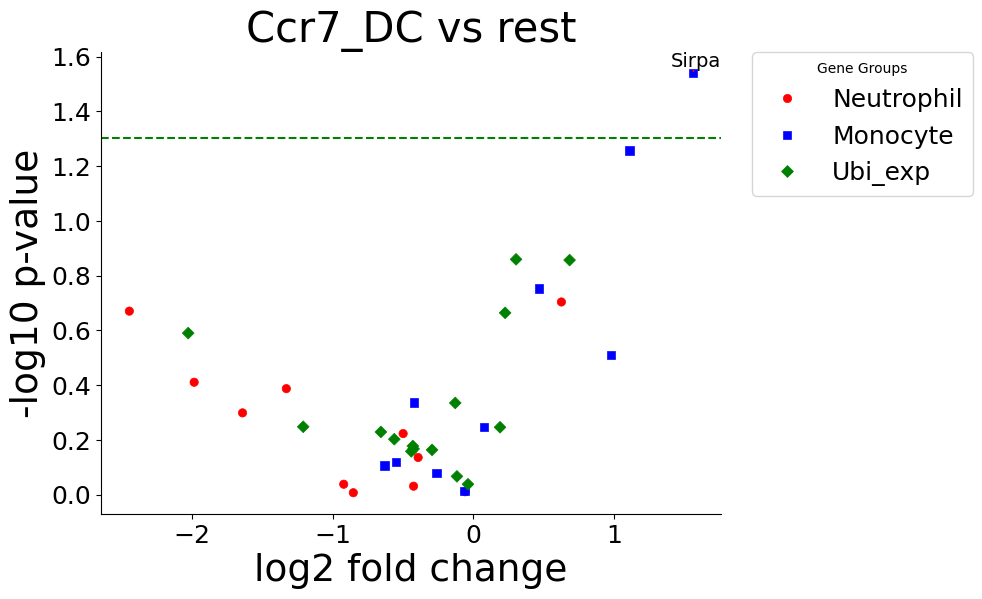

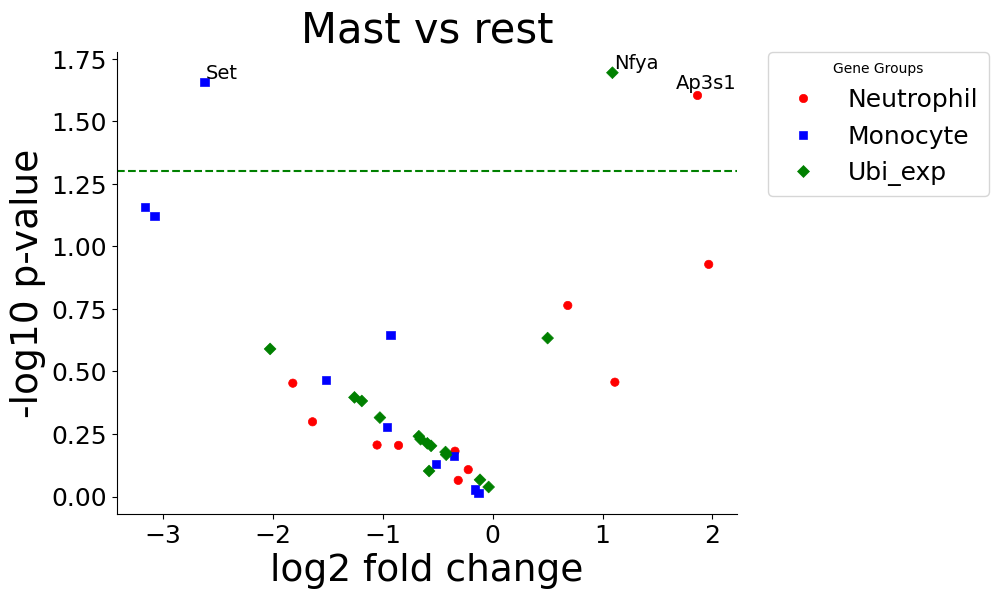

In [ ]:
# Create volcano plot from adata_t1 for gene expression for monocyte vs rest
from scipy.stats import mannwhitneyu

# Create volcano plot from adata_t1 for gene expression for monocyte vs rest
# def volcano_plot(adata, groupby, group, genes, pval_threshold=0.05):
#     # Subset data
#     adata_group1 = adata[adata.obs[groupby] == group]
#     adata_group2 = adata[adata.obs[groupby] != group]
#     mean_g1_list = []
#     mean_g2_list = []

#     # Initialize lists to store results
#     logfc_list = []
#     pval_list = []

#     # Iterate over genes
#     for gene in genes:
#         expr_group1 = np.expm1(adata_group1[:, gene].X.toarray()).flatten()
#         expr_group2 = np.expm1(adata_group2[:, gene].X.toarray()).flatten()

#         # Calculate log fold change
#         mean_group1 = np.mean(expr_group1)
#         mean_group2 = np.mean(expr_group2)
#         logfc = np.log2((mean_group1 + 1) / (mean_group2 + 1))  # add small constant to avoid division by zero
#         logfc_list.append(logfc)

#         # Perform Mann-Whitney U test
#         stat, pval = mannwhitneyu(expr_group1, expr_group2, alternative='two-sided')
#         pval_list.append(pval)
#         mean_g1_list.append(mean_group1)
#         mean_g2_list.append(mean_group2)
#     # Create DataFrame for plotting
#     df_results = pd.DataFrame({
#         'gene': genes,
#         'mean_g1': mean_g1_list,
#         'mean_g2': mean_g2_list,
#         'logFC': logfc_list,
#         'pval': pval_list
#     })
#     df_results['neg_log10_pval'] = -np.log10(df_results['pval'] + 1e-10)  # add small constant to avoid log(0)

#     # Determine significance
#     df_results['significant'] = df_results['pval'] <= pval_threshold

#     # Plot volcano plot
#     plt.figure(figsize=(8, 6))
#     sns.scatterplot(data=df_results, x='logFC', y='neg_log10_pval', hue='significant', palette={True: 'red', False: 'gray'}, edgecolor=None)
#     # Add text labels for significant genes
#     for _, row in df_results.iterrows():
#         if row['significant']:
#             plt.text(row['logFC'], row['neg_log10_pval'], row['gene'], fontsize=14)
#     # Add threshold line
#     plt.axhline(y=-np.log10(pval_threshold), color='green', linestyle='--')
#     sns.despine(right=True, top=True)
#     plt.title(f'{group} vs rest')
#     plt.xlabel('log2 fold change')
#     plt.ylabel('-log10 p-value')
#     # plt.legend(title='Significant')
#     # No legend
#     plt.legend([],[], frameon=False)
#     plt.show()
#     return df_results

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

def volcano_plot(adata, groupby, group, genes, pval_threshold=0.05, gene_list_Neutrophil=[], gene_list_monocyte=[], gene_list_ubi_exp=[]):
    # Subset data
    adata_group1 = adata[adata.obs[groupby] == group]
    adata_group2 = adata[adata.obs[groupby] != group]
    mean_g1_list = []
    mean_g2_list = []

    # Initialize lists to store results
    logfc_list = []
    pval_list = []
    gene_group_list = []  # List to store gene group information

    # Iterate over genes
    for gene in genes:
        expr_group1 = np.expm1(adata_group1[:, gene].X.toarray()).flatten()
        expr_group2 = np.expm1(adata_group2[:, gene].X.toarray()).flatten()

        # Calculate log fold change
        mean_group1 = np.mean(expr_group1)
        mean_group2 = np.mean(expr_group2)
        logfc = np.log2((mean_group1 + 1) / (mean_group2 + 1))  # add small constant to avoid division by zero
        logfc_list.append(logfc)

        # Perform Mann-Whitney U test
        stat, pval = mannwhitneyu(expr_group1, expr_group2, alternative='two-sided')
        pval_list.append(pval)
        mean_g1_list.append(mean_group1)
        mean_g2_list.append(mean_group2)

        # Determine gene group (Neutrophil, monocyte, ubi_exp)
        if gene in gene_list_Neutrophil:
            gene_group_list.append('Neutrophil')
        elif gene in gene_list_monocyte:
            gene_group_list.append('Monocyte')
        elif gene in gene_list_ubi_exp:
            gene_group_list.append('Ubi_exp')
        else:
            gene_group_list.append('Other')  # If the gene doesn't belong to any of the specified lists

    # Create DataFrame for plotting
    df_results = pd.DataFrame({
        'gene': genes,
        'mean_g1': mean_g1_list,
        'mean_g2': mean_g2_list,
        'logFC': logfc_list,
        'pval': pval_list,
        'gene_group': gene_group_list  # Add gene group to DataFrame
    })
    df_results['neg_log10_pval'] = -np.log10(df_results['pval'] + 1e-10)  # add small constant to avoid log(0)

    # Determine significance
    df_results['significant'] = df_results['pval'] <= pval_threshold

    # Plot volcano plot
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_results, x='logFC', y='neg_log10_pval', hue='gene_group', style='gene_group',
                    palette={'Neutrophil': 'red', 'Monocyte': 'blue', 'Ubi_exp': 'green', 'Other': 'gray'},
                    markers={'Neutrophil': 'o', 'Monocyte': 's', 'Ubi_exp': 'D', 'Other': 'X'}, edgecolor=None)

    # Add text labels for significant genes
    texts = []
    for _, row in df_results.iterrows():
        if row['significant']:
            texts.append(plt.text(row['logFC'], row['neg_log10_pval'], row['gene'], fontsize=14))

    # Adjust text labels to avoid overlap using adjustText
    adjust_text(texts, arrowprops=dict(arrowstyle="->", color='red'))

    # Add threshold line

    # Add threshold line
    plt.axhline(y=-np.log10(pval_threshold), color='green', linestyle='--')

    # Final plot settings
    sns.despine(right=True, top=True)
    plt.title(f'{group} vs rest')
    plt.xlabel('log2 fold change')
    plt.ylabel('-log10 p-value')

    # Legend for gene groups
    plt.legend(title='Gene Groups', bbox_to_anchor = (1.05, 1), loc=2, borderaxespad=0.)
    plt.show()

    return df_results


# To be replaced with gene list of interest
# genes = ['Brd9', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']
genes = gene_list
cell_type_list = adata_t1_undiff_high_CD34.obs['dominant_cell_type'].unique()
for cell_type in cell_type_list:
  if cell_type == "None":
    continue
  _ = volcano_plot(adata_t1_undiff_high_CD34, groupby='dominant_cell_type', group=cell_type, genes = gene_list, pval_threshold=0.05, gene_list_Neutrophil=gene_list_Neutrophil, gene_list_monocyte=gene_list_monocyte, gene_list_ubi_exp=gene_list_ubi_exp)

In [ ]:
########## OLD ##########

### Create input file
adata_t1 = adata_t1_clones_new
adata_t2 = adata[(adata.obs['Time point'] == t2) & (adata.obs['clone_id'] != -1)]
adata_t3 = adata[(adata.obs['Time point'] == t3) & (adata.obs['clone_id'] != -1)]

# Pick subset of genes
# gene_list = ['Muc13', 'Srgn', 'Ccl9', 'Elane', 'Igfbp4', 'Rbms1', 'Sirpa', 'Set', 'Tk1', 'Spp1']
# gene_list = ['Pou5f1', 'Sox2', 'Nanog', 'Klf4', 'Myc', 'Zfp42', 'Zfp281']
# gene_list = ['Brd9', 'Gata1', 'Wdr82', 'Smarcd2', 'Smarcd1', 'Bcl11a', 'Stag2', 'Setd1b', 'Gps2', 'Men1', 'Chd4', 'Kmt2a', 'Smc2', 'Phf10', 'Cbx3', 'Crebbp', 'Hdac3', 'Setdb2', 'Ehmt2', 'Mbd2', 'Setdb1', 'Rbbp4', 'Hdac1', 'Mbd3', 'Rcor1', 'Atf7ip', 'Hmgxb4', 'Carm1', 'Prmt5', 'Cebpa', 'Ash1l', 'Smarcb1', 'Ezh2', 'Chaf1a', 'Prmt1', 'Ehmt1', 'Smc4', 'Smc3', 'Chmp2a', 'Kdm6a', 'Spi1', 'Gata2']
# gene_subset = [s + '_mRNA' for s in gene_list]

# Find across t clones
across_t_clones = np.array(list(set(adata_t1.obs.clone_id.value_counts().index[adata_t1.obs.clone_id.value_counts() == 1]).intersection(adata_t2.obs.clone_id.unique())))

# From each clone, randomly pick a differentiated cell
t1_across_t_clones_cells = {}
t2_across_t_clones_cells = {}
adata_t2_across = adata_t2[adata_t2.obs.clone_id.isin(across_t_clones)]
for clone in across_t_clones:
    t1_across_t_clones_cells[clone] = adata_t1[adata_t1.obs.clone_id == clone].obs_names[0]
    idx = adata_t2_across[adata_t2_across.obs.clone_id == clone].obs_names
    t2_across_t_clones_cells[clone] = np.random.choice(idx, size=1)[0]

# create csv file
across_t_data_t1 = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
across_t_data_t1['cell_id'] = list(t1_across_t_clones_cells.values())
across_t_data_t1['clone_id'] = list(t1_across_t_clones_cells.keys())
across_t_data_t1['time_step'] = np.repeat(t1, len(across_t_data_t1))
across_t_data_t1['replicate'] = np.repeat(1, len(across_t_data_t1))
across_t_data_t1[gene_subset] = adata_t1[across_t_data_t1['cell_id'], gene_list].X.toarray()

across_t_data_t2 = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
across_t_data_t2['cell_id'] = list(t2_across_t_clones_cells.values())
across_t_data_t2['clone_id'] = list(t2_across_t_clones_cells.keys())
across_t_data_t2['time_step'] = np.repeat(t2, len(across_t_data_t2))
across_t_data_t2['replicate'] = np.repeat(2, len(across_t_data_t2))
across_t_data_t2[gene_subset] = adata_t2[across_t_data_t2['cell_id'], gene_list].X.toarray()

across_t_data = pd.concat([across_t_data_t1, across_t_data_t2])
# across_t_data.to_csv('LARRY_across_t_twins.csv')

# Excluding across t clones, pick all two-cell clones from t1
temp = adata_t1[~adata_t1.obs.clone_id.isin(across_t_clones)].obs.clone_id.value_counts()
t1_clones = np.array(list(temp.index[temp == 2]))

# create csv file
t1_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
t1_data['cell_id'] = adata_t1[adata_t1.obs.clone_id.isin(t1_clones)].obs_names
t1_data['clone_id'] = adata_t1[adata_t1.obs.clone_id.isin(t1_clones)].obs['clone_id'].values
t1_data['time_step'] = np.repeat(t1, len(t1_data))
t1_data['replicate'] = t1_data.groupby("clone_id").cumcount() + 1
t1_data[gene_subset] = adata_t1[t1_data['cell_id'], gene_list].X.toarray()
# t1_data.to_csv('/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis_new/LARRY_t1_twins.csv')

# Excluding across t clones, find clones with 2 cells
temp = adata_t2[(~adata_t2.obs.clone_id.isin(across_t_clones)) & (~adata_t2.obs.clone_id.isin(t1_clones))].obs.clone_id.value_counts()
# t2_clones = np.array(list(temp.index[temp == 2]))
t2_clones = np.array(list(temp.index[temp != 1]))

# From each of these clones, randomly pick two cells
adata_t2_within = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)]
t2_within_clones_cells = {}
for clone in t2_clones:
    idx = adata_t2_within[adata_t2_within.obs.clone_id == clone].obs_names
    t2_within_clones_cells[clone] = list(np.random.choice(idx, size=2))

t2_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
# t2_data['cell_id'] = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)].obs_names
# t2_data['clone_id'] = adata_t2[adata_t2.obs.clone_id.isin(t2_clones)].obs['clone_id'].values
t2_data['cell_id'] = np.array(list(t2_within_clones_cells.values())).reshape(-1)
t2_data['clone_id'] = np.repeat(np.array(list(t2_within_clones_cells.keys())), 2)
t2_data['time_step'] = np.repeat(t2, len(t2_data))
t2_data['replicate'] = t2_data.groupby("clone_id").cumcount() + 1
t2_data[gene_subset] = adata_t2[t2_data['cell_id'], gene_list].X.toarray()
# t2_data.to_csv('/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis_new/LARRY_t2_twins.csv')

# Subsample if t1_data << t2_data
if int(t1_data.shape[0]/2)*1.5 <= int(t2_data.shape[0]/2):
    t2_clones = t2_data.clone_id.unique()
    np.random.seed(42)
    t2_clones_sub = np.random.choice(t2_clones, size=int(t1_data.shape[0]/2), replace=False)
    t2_data = t2_data[t2_data.clone_id.isin(t2_clones_sub)]

temp = adata_t3.obs.clone_id.value_counts()
t3_clones = np.array(list(temp.index[temp == 2]))

# create csv file
t3_data = pd.DataFrame(columns=['clone_id', 'cell_id', 'time_step', 'replicate'] + gene_subset)
t3_data['cell_id'] = adata_t3[adata_t3.obs.clone_id.isin(t3_clones)].obs_names
t3_data['clone_id'] = adata_t3[adata_t3.obs.clone_id.isin(t3_clones)].obs['clone_id'].values
t3_data['time_step'] = np.repeat(t3, len(t3_data))
t3_data['replicate'] = t3_data.groupby("clone_id").cumcount() + 1
t3_data[gene_subset] = adata_t3[t3_data['cell_id'], gene_list].X.toarray()
# t3_data.to_csv("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis_new/LARRY_t3_twins.csv")
# t1_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_t1_twins.csv', index_col=0, sep=',')
# t2_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_t2_twins.csv', index_col=0, sep=',')
# across_t_data = pd.read_csv('/Users/idabueschel/Code/twINFER/TwINFER/LARRY_across_t_twins.csv', index_col=0, sep=',')

twin_data = pd.concat([t1_data, t2_data, across_t_data])
# twin_data.to_csv('LARRY_twins.csv')

print(f"Number of t1 twins: {int(t1_data.shape[0]/2)}")
print(f"Number of t2 twins: {int(t2_data.shape[0]/2)}")
print(f"Number of t3 twins: {int(t3_data.shape[0]/2)}")
print(f"Number of across t twins: {int(across_t_data.shape[0]/2)}")

NameError: name 'adata_t1_clones_new' is not defined

In [ ]:
adata_temp = adata_t1[adata_t1.obs['clone_id'].isin(t1_data.clone_id.unique()), gene_list].copy()
for gene in gene_list:
    fig, ax = plt.subplots(1,2, figsize=(8,3))
    data = adata_temp[:, gene].X.toarray()
    ax[0].hist(data)
    ax[1].hist(data[data != 0])
    plt.suptitle(gene)
    plt.show()

sc.pl.umap(adata_temp, color=['Cell type annotation'] + gene_list, cmap='Reds')

In [ ]:
adata_temp = adata_t2[adata_t2.obs['clone_id'].isin(t2_data.clone_id.unique()), gene_list].copy()
for gene in gene_list:
    fig, ax = plt.subplots(1,2, figsize=(8,3))
    data = adata_temp[:, gene].X.toarray()
    ax[0].hist(data)
    ax[1].hist(data[data != 0])
    plt.suptitle(gene)
    plt.show()

sc.pl.umap(adata_temp, color=['Cell type annotation'] + gene_list, cmap='Reds')

In [ ]:
# Calculation functions
import importlib
import sys
import os

# Add the current directory to sys.path to ensure module discovery
current_dir = f"{data_path}/TwINFER"
if current_dir not in sys.path:
    sys.path.insert(0, f"{data_path}/TwINFER")

from TwINFER_function_scripts import correlation_analysis_functions
from TwINFER_function_scripts import correlation_analysis_helpers

importlib.reload(correlation_analysis_functions)
importlib.reload(correlation_analysis_helpers)

from TwINFER_function_scripts.correlation_analysis_functions import (

    calculate_pairwise_gene_gene_correlation_matrix,
    check_system_in_steady_state,
    check_gene_gene_correlation_threshold,
    calculate_twin_random_pair_correlations,
    differentiate_single_state_reg_and_multiple_states,
    identify_reg_if_multiple_states,
    get_cross_correlations,
    identify_actual_directed_edges
)

# Helper functions
from TwINFER_function_scripts.correlation_analysis_helpers import (
    extract_param_index,
    read_input_matrix,
    get_param_data,
    plot_matrix_as_heatmap,
    print_summary,
    plot_network
)

In [ ]:
# Drop column clone_id and rename pair_id to clone_id
# t1_data.drop(columns=['clone_id'], inplace=True)
# t1_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
# t2_data.drop(columns=['clone_id'], inplace=True)
# t2_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)
# t3_data.drop(columns=['clone_id'], inplace=True)
# t3_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

# across_t_data.drop(columns=['clone_id'], inplace=True)
# across_t_data.rename(columns={'pair_id': 'clone_id'}, inplace=True)

t1_clones = t1_data.clone_id.values
t2_clones = t2_data.clone_id.values
t3_clones = t3_data.clone_id.values
across_t_clones = across_t_data.clone_id.values

# Subset directly
t1_twins = t1_data
t2_twins = t2_data
t3_twins = t3_data

# Across_t: pick exactly one random twin per clone_id
# One cell per clone at t1
across_t_twin1 = across_t_data[across_t_data.time_step == t1]
across_t_twin2 = across_t_data[across_t_data.time_step == t2]

# Reset index for cleanliness
t1_twins = t1_twins.reset_index(drop=True)
t2_twins = t2_twins.reset_index(drop=True)
t3_twins = t3_twins.reset_index(drop=True)
across_t_twin1 = across_t_twin1.reset_index(drop=True)
across_t_twin2 = across_t_twin2.reset_index(drop=True)

all_t1_t2_measurements = pd.concat(
[t1_twins, t2_twins, across_t_twin1, across_t_twin2],
ignore_index=True
)

all_t1_measurements = pd.concat(
[t1_twins, across_t_twin1],
ignore_index=True
)
all_t2_measurements = pd.concat(
[t2_twins, across_t_twin2],
ignore_index=True
)

all_t3_measurements = t3_twins

In [ ]:
# Define input parameters
plot_correlation_matrices_as_heatmap = True
have_any_output = True
p_val_threshold_scrambled_gene_correlation = 0.05
show_scrambled_distribution_gene_correlation = False
z_score_threshold_two_states = 10

Number of CPU cores available: 44


           Muc13      Srgn      Ccl9     Plac8     Snrpf     Prtn3     Elane  \
Muc13   1.000000  0.192173  0.164958 -0.069429  0.063909  0.038138  0.054786   
Srgn    0.192173  1.000000  0.280538  0.140241  0.025654  0.202196  0.290530   
Ccl9    0.164958  0.280538  1.000000  0.079456  0.060509  0.204465  0.186852   
Plac8  -0.069429  0.140241  0.079456  1.000000  0.056574  0.208580  0.274866   
Snrpf   0.063909  0.025654  0.060509  0.056574  1.000000  0.102017  0.066358   
Prtn3   0.038138  0.202196  0.204465  0.208580  0.102017  1.000000  0.441531   
Elane   0.054786  0.290530  0.186852  0.274866  0.066358  0.441531  1.000000   
Igfbp4  0.096759  0.065873  0.143678 -0.029571  0.024927  0.039291  0.044684   
Ap3s1   0.067849  0.293470  0.189684  0.268705  0.123904  0.341875  0.355902   
Ctsg    0.028985  0.291422  0.250208  0.299925  0.100294  0.436827  0.564023   
Cd34    0.069528 -0.060618  0.067229 -0.079846  0.008468  0.008801 -0.037429   

          Igfbp4     Ap3s1      Ctsg   

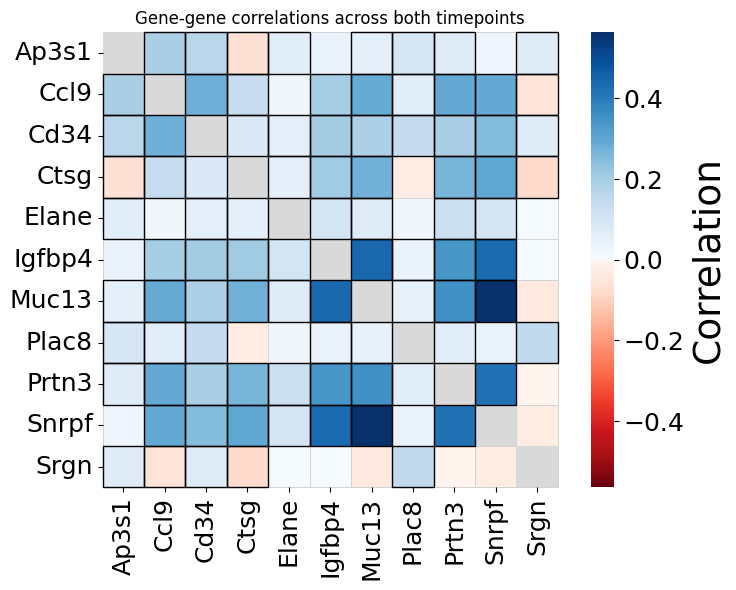

In [ ]:
# --- Step 1: Pairwise gene-gene correlations at t1: day 2 ---
pairwise_gene_gene_correlation_matrix_t1 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t1_measurements, gene_list
)
print(pairwise_gene_gene_correlation_matrix_t1)
no_regulation_t1, potential_regulation_t1, _ = check_gene_gene_correlation_threshold(
    all_t1_measurements, pairwise_gene_gene_correlation_matrix_t1, gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation, n_cores_to_use=42
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations across both timepoints", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self=True
    )

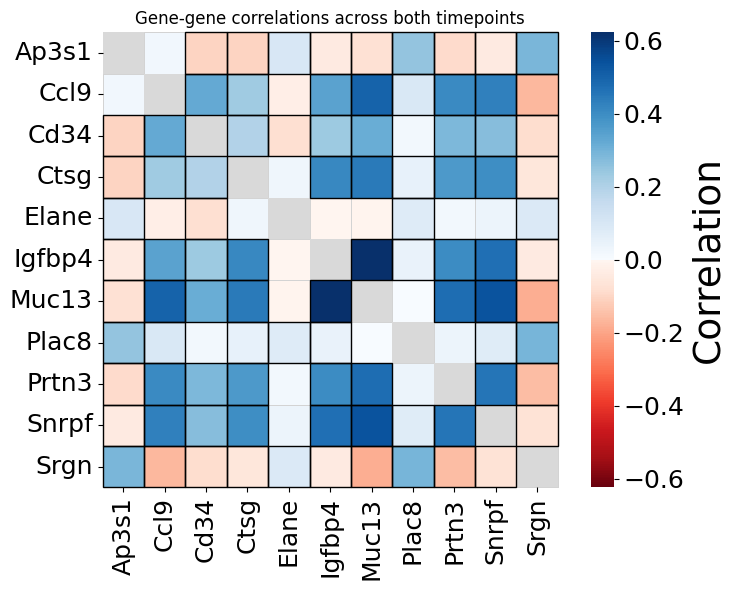

In [ ]:
# --- Step 1: Pairwise gene-gene correlations at t1: day 4 ---
pairwise_gene_gene_correlation_matrix_t2 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t2_measurements, gene_list
)
no_regulation_t2, potential_regulation_t2, _ = check_gene_gene_correlation_threshold(
    all_t2_measurements, pairwise_gene_gene_correlation_matrix_t2, gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation,  n_cores_to_use=9
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=potential_regulation_t2,
        title=f"Gene-gene correlations across both timepoints", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True
    )

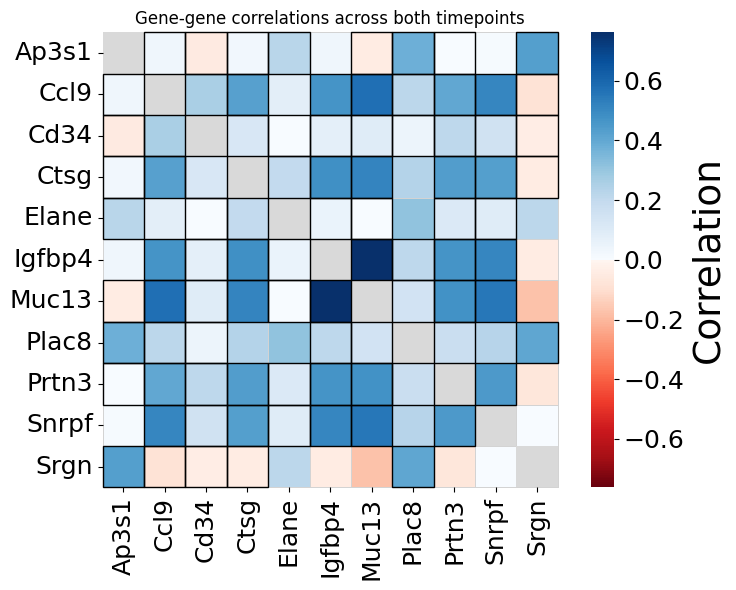

In [ ]:
# --- Step 1: Pairwise gene-gene correlations at t3: day 6 ---
pairwise_gene_gene_correlation_matrix_t3 = calculate_pairwise_gene_gene_correlation_matrix(
    all_t3_measurements, gene_list
)
no_regulation_t3, potential_regulation_t3,_ = check_gene_gene_correlation_threshold(
    all_t3_measurements, pairwise_gene_gene_correlation_matrix_t3, gene_list, use_scramble = True, p_val_threshold = p_val_threshold_scrambled_gene_correlation, verbose = show_scrambled_distribution_gene_correlation, n_cores_to_use=44
)

# print(no_regulation)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=potential_regulation_t1,
        title=f"Gene-gene correlations across both timepoints", add_gene_labels=True, add_time=False, gray_out_no_reg=False,black_out_self = True
    )

In [ ]:
import pandas as pd
from itertools import product
from pathlib import Path

out_dir = Path(data_path)
out_dir.mkdir(exist_ok=True)

# === Combine and save all timepoint results ===
rows = []

for tp, (no_reg, pot_reg, corr_mat) in {
    "t1": (no_regulation_t1, potential_regulation_t1, pairwise_gene_gene_correlation_matrix_t1),
    "t2": (no_regulation_t2, potential_regulation_t2, pairwise_gene_gene_correlation_matrix_t2),
    # "t3": (no_regulation_t3, potential_regulation_t3, pairwise_gene_gene_correlation_matrix_t3),
}.items():

    all_pairs = set(tuple(sorted(p)) for p in no_reg + pot_reg)

    for g1, g2 in all_pairs:
        # lookup correlation (try both orders)
        if g1 in corr_mat.index and g2 in corr_mat.columns:
            corr_val = corr_mat.loc[g1, g2]
        elif g2 in corr_mat.index and g1 in corr_mat.columns:
            corr_val = corr_mat.loc[g2, g1]
        else:
            corr_val = None

        pair_sorted = tuple(sorted((g1, g2)))
        if pair_sorted in [tuple(sorted(p)) for p in pot_reg]:
            category = "potential_regulation"
        elif pair_sorted in [tuple(sorted(p)) for p in no_reg]:
            category = "no_regulation"
        else:
            category = "uncategorized"

        rows.append([g1, g2, corr_val, category, tp])

# Create DataFrame
from datetime import datetime
df = pd.DataFrame(rows, columns=["gene_1", "gene_2", "correlation", "category", "timepoint"])

# Get current date and time
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Define output filename with timestamp
outfile = out_dir / f"gene_pair_results_all_timepoints_old_{timestamp}.csv"

# Save file
df.to_csv(outfile, index=False)

# Print confirmation with readable date/time
print(f"✅ [{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Saved {len(df)} pairs to {outfile.name}")




✅ [2025-12-11 21:45:33] Saved 110 pairs to gene_pair_results_all_timepoints_old_20251211_214533.csv


In [ ]:
import pandas as pd
from pathlib import Path

# === Load saved CSV ===
# out_dir = Path("/home/gzu5140/Keerthana_b1042/grnInference/analysisData/real_data_analysis/")
df = pd.read_csv(out_dir / "gene_pair_results_all_timepoints.csv")

# === Reconstruct lists and matrices ===
no_regulation = {}
potential_regulation = {}
pairwise_gene_gene_correlation_matrix = {}

for tp, sub in df.groupby("timepoint"):
    # Lists of tuples
    no_regulation[tp] = list(zip(sub.loc[sub["category"] == "no_regulation", "gene_1"],
                                 sub.loc[sub["category"] == "no_regulation", "gene_2"]))
    potential_regulation[tp] = list(zip(sub.loc[sub["category"] == "potential_regulation", "gene_1"],
                                        sub.loc[sub["category"] == "potential_regulation", "gene_2"]))
    # Pivot to matrix
    corr_mat = sub.pivot_table(index="gene_1", columns="gene_2", values="correlation")
    # make symmetric since we only stored one order per pair
    corr_mat = corr_mat.combine_first(corr_mat.T)
    pairwise_gene_gene_correlation_matrix[tp] = corr_mat

# === Extract t1, t2, t3 structures ===
no_regulation_t1 = no_regulation["t1"]
no_regulation_t2 = no_regulation["t2"]
no_regulation_t3 = no_regulation["t3"]

potential_regulation_t1 = potential_regulation["t1"]
potential_regulation_t2 = potential_regulation["t2"]
potential_regulation_t3 = potential_regulation["t3"]

pairwise_gene_gene_correlation_matrix_t1 = pairwise_gene_gene_correlation_matrix["t1"]
pairwise_gene_gene_correlation_matrix_t2 = pairwise_gene_gene_correlation_matrix["t2"]
pairwise_gene_gene_correlation_matrix_t3 = pairwise_gene_gene_correlation_matrix["t3"]

# Optional sanity check
for tp in ["t1", "t2", "t3"]:
    print(f"{tp}: {len(no_regulation[tp])} no-reg pairs, "
          f"{len(potential_regulation[tp])} potential-reg pairs, "
          f"matrix {pairwise_gene_gene_correlation_matrix[tp].shape}")


In [ ]:
consistent_corr = list((set(potential_regulation_t1).intersection(set(potential_regulation_t2))).intersection(set(potential_regulation_t3)))
len(consistent_corr)
print(consistent_corr)

[('Srgn', 'Elane'), ('Ccl9', 'Plac8'), ('Muc13', 'Snrpf'), ('Plac8', 'Prtn3'), ('Plac8', 'Ctsg'), ('Srgn', 'Igfbp4'), ('Srgn', 'Ccl9'), ('Prtn3', 'Elane'), ('Ap3s1', 'Ctsg'), ('Srgn', 'Ap3s1'), ('Prtn3', 'Igfbp4'), ('Elane', 'Ap3s1'), ('Srgn', 'Prtn3'), ('Srgn', 'Ctsg'), ('Prtn3', 'Ap3s1'), ('Srgn', 'Plac8'), ('Ccl9', 'Elane'), ('Muc13', 'Cd34'), ('Elane', 'Ctsg'), ('Prtn3', 'Ctsg'), ('Igfbp4', 'Cd34'), ('Plac8', 'Elane'), ('Srgn', 'Cd34'), ('Ccl9', 'Ap3s1'), ('Ccl9', 'Prtn3'), ('Ccl9', 'Ctsg'), ('Plac8', 'Ap3s1'), ('Muc13', 'Igfbp4')]


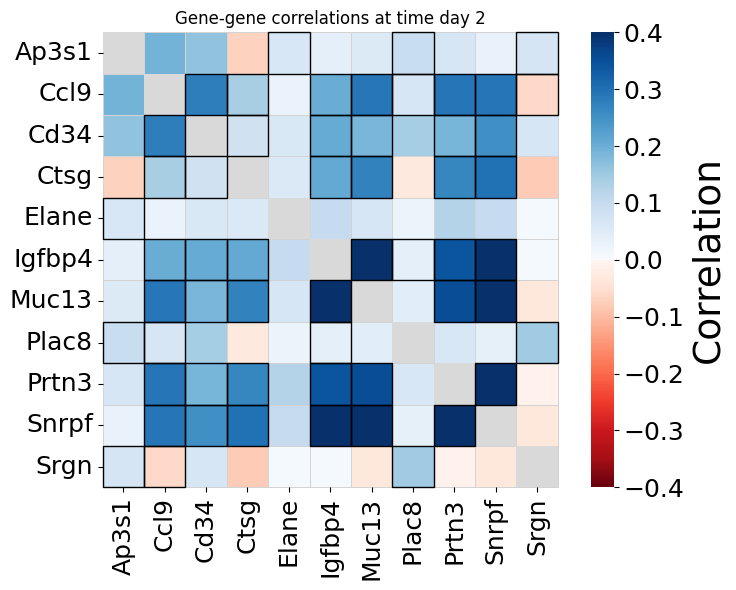

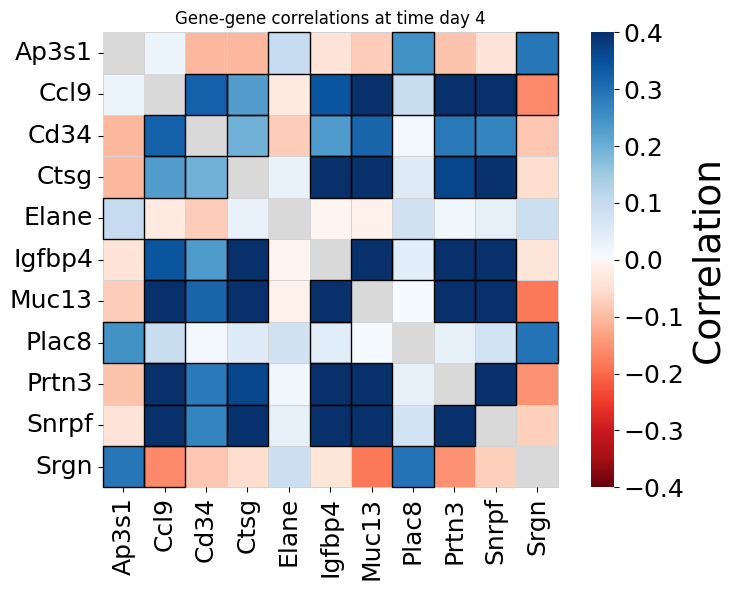

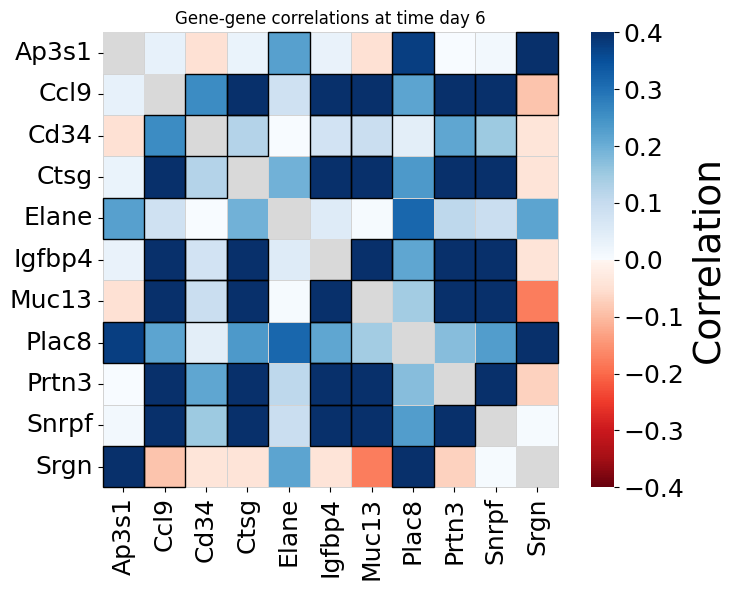

In [ ]:
#Plot all 3 timepoints highlight the consistent correlations
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene-gene correlations at time day 2", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True, vmin = -0.4, vmax = 0.4
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene-gene correlations at time day 4", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True, vmin = -0.4, vmax = 0.4
    )
plot_matrix_as_heatmap(corr_matrix=pairwise_gene_gene_correlation_matrix_t3, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Gene-gene correlations at time day 6", add_gene_labels=True, add_time=False, gray_out_no_reg=False, black_out_self = True, vmin = -0.4, vmax = 0.4
    )

In [ ]:
### plotting functions ###

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import TwoSlopeNorm, Normalize, LinearSegmentedColormap

def make_reds_blues_colormap():
    reds = plt.cm.Reds(np.linspace(1, 0, 128))   # deep red → white
    blues = plt.cm.Blues(np.linspace(0, 1, 128)) # white → deep blue
    colors = np.vstack((reds, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

def plot_matrix_as_heatmap(corr_matrix, gene_list, no_regulation=None, potential_regulation=None, title=None, add_gene_labels=True,
                            add_time=False, time=None, gray_out_no_reg=False, vmin=None, vmax=None, cmap=None,
                            return_plot=False, black_out_self=False):
    """
    Plot a gene-gene correlation matrix as a heatmap with regulatory overlays and dynamic formatting.
    """

    if add_time:
        if time is None or not isinstance(time, (list, tuple)) or len(time) == 0:
            raise ValueError("If add_time=True, you must provide a non-empty list of 1 or 2 time values in `time`.")
        if len(time) > 2:
            raise ValueError("Time can have at most two entries.")

    # Format gene names: gene_1 → g1
    base_names = [g.replace("gene_", "g") for g in gene_list]

    # Format axis labels
    if add_gene_labels:
        if add_time:
            if len(time) == 1:
                # row_labels = [f"$g{i}_{{{time[0]}}}$" for i in range(1, len(base_names) + 1)]
                # col_labels = row_labels
                row_labels = gene_list
                col_labels = gene_list
            else:
                # row_labels = [f"$g{i}_{{{time[0]}}}$" for i in range(1, len(base_names) + 1)]
                # col_labels = [f"$g{i}_{{{time[1]}}}$" for i in range(1, len(base_names) + 1)]
                row_labels = [f"${gene}_{{{time[0]}}}$" for gene in gene_list]
                col_labels = [f"${gene}_{{{time[1]}}}$" for gene in gene_list]
        else:
            row_labels = base_names
            col_labels = base_names
    else:
        row_labels = [""] * len(gene_list)
        col_labels = [""] * len(gene_list)

    # Prepare plot matrix
    plot_matrix = corr_matrix.copy()

    # --- Handle masking ---
    mask = np.zeros_like(plot_matrix.values, dtype=bool)
    if gray_out_no_reg and no_regulation:
        for g1, g2 in no_regulation:
            if g1 in gene_list and g2 in gene_list:
                i = gene_list.index(g1)
                j = gene_list.index(g2)
                plot_matrix.iloc[i, j] = 0
                mask[i, j] = True

    # --- Handle vmin/vmax auto-scaling ---
    data_values = plot_matrix.values.flatten()
    data_values = data_values[~np.isnan(data_values)]

    if len(data_values) == 0:
        vmin, vmax = -1.0, 1.0
    else:
        if vmin is None:
            vmin = np.min(data_values)
        if vmax is None:
            vmax = np.max(data_values)
        if vmin == vmax:
            vmin -= 1e-4
            vmax += 1e-4

    # --- Choose colormap adaptively ---
    if cmap is None and vmin < 0 and vmax > 0:
        cmap = make_reds_blues_colormap()
        center_span = max(abs(vmin), abs(vmax))
        norm = TwoSlopeNorm(vmin=-center_span, vcenter=0.0, vmax=center_span)
    else:
        norm = None
        if cmap is None:
            cmap = "Blues" if vmin >= 0 else "Reds"

    # --- Plot heatmap ---
    fig, ax = plt.subplots(figsize=(8, 6))

    # --- Black out diagonal if requested ---
    if black_out_self:
        for k in range(len(gene_list)):
            rect = Rectangle((k, k), 1, 1, facecolor='#D9D9D9', edgecolor='#D9D9D9')
            ax.add_patch(rect)
    heatmap = sns.heatmap(
        plot_matrix,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        norm=norm,
        xticklabels=col_labels,
        yticklabels=row_labels,
        square=True,
        cbar_kws={'label': 'Correlation'},
        linewidths=0.5,
        linecolor='lightgray',
        mask=mask
    )

    # --- Add regulation boxes ---
    if potential_regulation:
        for g1, g2 in potential_regulation:
            if g1 in gene_list and g2 in gene_list:
                i = gene_list.index(g1)
                j = gene_list.index(g2)
                rect = Rectangle((j, i), 1, 1, fill=False, edgecolor='black', linewidth=2)
                ax.add_patch(rect)

    # --- Title ---
    if title:
        if add_time:
            if len(time) == 1:
                title += f" @ time d{time[0]}"
            elif len(time) == 2:
                title += f" (rows: d{time[0]}, cols: d{time[1]})"
        ax.set_title(title, fontsize=12)

    plt.tight_layout()
    if return_plot:
        return fig, ax
    else:
        plt.show()


In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1 = calculate_twin_random_pair_correlations(
    all_t1_measurements, t1_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t1}", add_gene_labels=True, add_time=True, time=[t1], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1, gene_list=gene_list, no_regulation=no_regulation_t1, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t1], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1, single_state_regulation_t1 = differentiate_single_state_reg_and_multiple_states(
    all_t1_measurements, consistent_corr, twin_pair_correlation_matrix_t1, random_pair_correlation_matrix_t1, gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t1, single_state_regulation_t1)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2 = calculate_twin_random_pair_correlations(
    all_t2_measurements, t2_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t2, single_state_regulation_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t2_measurements, consistent_corr, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t2, gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t2, single_state_regulation_t2)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# --- Step 2: Twin/random correlations at t3 ---
twin_pair_correlation_matrix_t3, random_pair_correlation_matrix_t3 = calculate_twin_random_pair_correlations(
    all_t3_measurements, t3_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t3, gene_list=gene_list, no_regulation=no_regulation_t3, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t3], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t3, gene_list=gene_list, no_regulation=no_regulation_t3, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t3, single_state_regulation_t3 = differentiate_single_state_reg_and_multiple_states(
    all_t3_measurements, consistent_corr, twin_pair_correlation_matrix_t3, random_pair_correlation_matrix_t3, gene_list, z_score_threshold=z_score_threshold_two_states
)
print(multiple_states_gene_pairs_t3, single_state_regulation_t3)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# --- Step 2: Twin/random correlations at t2 ---
twin_pair_correlation_matrix_t1_t2, random_pair_correlation_matrix_t1_t2 = calculate_twin_random_pair_correlations(
    all_t1_t2_measurements, t2_twins, gene_list
)
# print(twin_pair_correlation_matrix_t2)
if plot_correlation_matrices_as_heatmap:
    plot_matrix_as_heatmap( corr_matrix=twin_pair_correlation_matrix_t1_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Twin pair correlations at time d{t2}", add_gene_labels=True, add_time=True, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

    plot_matrix_as_heatmap( corr_matrix=random_pair_correlation_matrix_t1_t2, gene_list=gene_list, no_regulation=no_regulation_t2, potential_regulation=consistent_corr,
        title=f"Random pair correlations across both time points", add_gene_labels=True, add_time=False, time=[t2], gray_out_no_reg=True, vmin = -0.4, vmax=0.4, black_out_self=True
    )

# --- Step 3: Classify regulation type: single-state vs multiple-states ---
multiple_states_gene_pairs_t1_t2, single_state_regulation_t1_t2 = differentiate_single_state_reg_and_multiple_states(
    all_t1_t2_measurements, consistent_corr, twin_pair_correlation_matrix_t2, random_pair_correlation_matrix_t1_t2, gene_list, z_score_threshold=z_score_threshold_two_states
)

In [ ]:
if len(multiple_states_gene_pairs_t1) > 0:

    multiple_states_no_reg, multiple_states_and_reg = identify_reg_if_multiple_states(
        twin_pair_correlation_matrix_t1,twin_pair_correlation_matrix_t2,random_pair_correlation_matrix_t1,
        random_pair_correlation_matrix_t2,multiple_states_gene_pairs_t1,gene_list
        )
else:
    multiple_states_no_reg, multiple_states_and_reg = [], []

Testing for multiple states. Correlation at time t1 = 0.09388831511364039 and at time t2 = 0.14174186536618527
Testing for multiple states. Correlation at time t1 = 0.004939137765600277 and at time t2 = -0.02965229059304546
Testing for multiple states. Correlation at time t1 = 0.080094298985347 and at time t2 = 0.058521960372796264
Testing for multiple states. Correlation at time t1 = 0.09225672179650621 and at time t2 = 0.14609056692401431
Testing for multiple states. Correlation at time t1 = 0.17288827183825026 and at time t2 = 0.20793091854448395
Testing for multiple states. Correlation at time t1 = 0.1439894144767521 and at time t2 = 0.03817744029913194
Testing for multiple states. Correlation at time t1 = 0.02302371873576518 and at time t2 = 0.08077340004940566
Testing for multiple states. Correlation at time t1 = 0.05609528285108092 and at time t2 = 0.07230733128581482
Testing for multiple states. Correlation at time t1 = 0.015107045394574749 and at time t2 = 0.10772454392201064


In [ ]:
# --- Step 4: Print summary of results ---
all_gene_pairs = list(product(gene_list, repeat=2))
if have_any_output:
    print_summary(no_regulation_t1, single_state_regulation_t1, multiple_states_no_reg, multiple_states_and_reg)


1. No Regulation
  Muc13 - Prtn3
  Muc13 - Ctsg
  Srgn - Snrpf
  Plac8 - Igfbp4
  Snrpf - Igfbp4
  Snrpf - Cd34
  Prtn3 - Cd34
  Elane - Cd34
  Igfbp4 - Ctsg
  Ap3s1 - Cd34
  Ctsg - Cd34

2. Single-State Regulation
  Ccl9 - Plac8
  Muc13 - Snrpf
  Srgn - Igfbp4
  Prtn3 - Igfbp4
  Srgn - Plac8
  Ccl9 - Elane
  Muc13 - Cd34
  Igfbp4 - Cd34
  Plac8 - Elane
  Srgn - Cd34
  Ccl9 - Ap3s1
  Ccl9 - Prtn3
  Ccl9 - Ctsg
  Muc13 - Igfbp4

3. Multiple States (No Regulation)
  Plac8 - Prtn3
  Plac8 - Ctsg
  Ap3s1 - Ctsg
  Prtn3 - Ap3s1
  Plac8 - Ap3s1

4. Multiple States with Regulation
  Srgn - Elane
  Srgn - Ccl9
  Prtn3 - Elane
  Srgn - Ap3s1
  Elane - Ap3s1
  Srgn - Prtn3
  Srgn - Ctsg
  Elane - Ctsg
  Prtn3 - Ctsg


In [ ]:
len(final_directed_edges)

50

In [ ]:
# --- Step 5: Infer directionality of single-state interactions ---
infer_direction_for_which_edges = "all-regulation"
p_value_threshold_cross_correlation = 0.01
n_cores = 42


['Ap3s1', 'Ccl9', 'Cd34', 'Ctsg', 'Elane', 'Igfbp4', 'Muc13', 'Plac8', 'Prtn3', 'Snrpf', 'Srgn']
Srgn -> Elane: threshold = 0.10664152904071536, actual = 0.10263282167151545
Ap3s1 -> Ccl9: threshold = 0.10722926506960466, actual = 0.12295216329308775
Ccl9 -> Plac8: threshold = 0.1082848483816139, actual = 0.05134151728327271
Ap3s1 -> Ap3s1: threshold = 0.10393520906879562, actual = 0.14590912276625662
Srgn -> Srgn: threshold = 0.10535691333369081, actual = 0.22838329589905462
Igfbp4 -> Igfbp4: threshold = 0.10673588839639345, actual = 0.15882384933345164
Cd34 -> Muc13: threshold = 0.10725545371417786, actual = 0.012353228578203717
Muc13 -> Snrpf: threshold = 0.10682072734911162, actual = 0.035129805845207425
Ctsg -> Prtn3: threshold = 0.10641567568053416, actual = 0.11721677277781122
Ctsg -> Ctsg: threshold = 0.10581094867954555, actual = 0.06088963697598215
Srgn -> Igfbp4: threshold = 0.10545120213746234, actual = -0.00402408745112551
Elane -> Elane: threshold = 0.10668848217278301, a

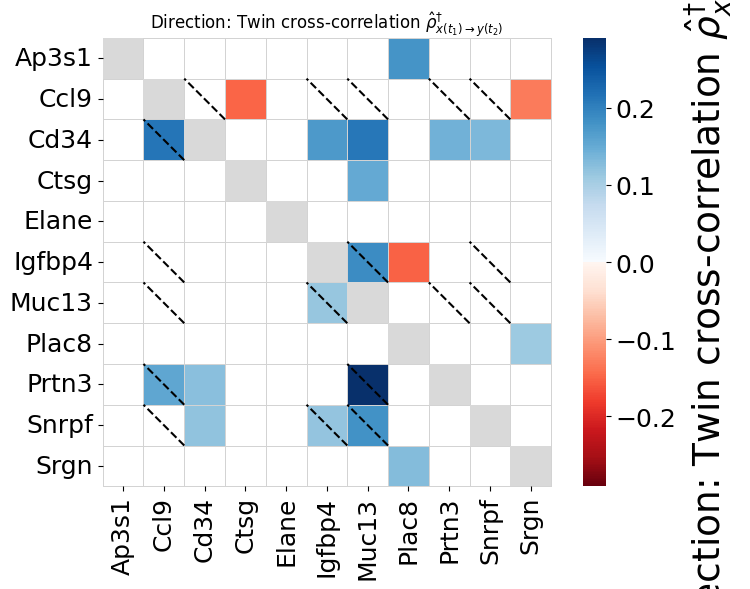

In [ ]:
if infer_direction_for_which_edges == "single-state" :
    if len(single_state_regulation_t1) > 0:
        bidirectional_pairs = {(a, b) for (a, b) in single_state_regulation_t1} | \
                  {(b, a) for (a, b) in single_state_regulation_t1}
        # Add self-pairs
        genes = {g for pair in single_state_regulation_t1 for g in pair}
        self_pairs = {(g, g) for g in genes}
        # Final
        all_gene_pairs = bidirectional_pairs | self_pairs
        all_gene_pairs = list(all_gene_pairs)
        direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)

        final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)

elif infer_direction_for_which_edges == "all-regulation":
    if len(single_state_regulation_t1) > 0 or len(multiple_states_and_reg):
            combined_list = single_state_regulation_t1 + multiple_states_and_reg
            bidirectional_pairs = {(a, b) for (a, b) in combined_list} | \
                  {(b, a) for (a, b) in combined_list}
            genes = {g for pair in single_state_regulation_t1 for g in pair}
            self_pairs = {(g, g) for g in genes}
            # Final
            all_gene_pairs_all_reg = bidirectional_pairs | self_pairs
            all_gene_pairs_all_reg = list(all_gene_pairs_all_reg)
            direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs_all_reg)
            final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs_all_reg, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
    else:
            final_directed_edges = []
            direction_matrix = pd.DataFrame(
                np.zeros((len(gene_list), len(gene_list))),
                index=gene_list,
                columns=gene_list
            )
else:
    direction_matrix = get_cross_correlations(across_t_twin1, across_t_twin2, gene_pairs=all_gene_pairs)
    final_directed_edges = identify_actual_directed_edges(across_t_twin1, across_t_twin2, direction_matrix, gene_pairs=all_gene_pairs, threshold = p_value_threshold_cross_correlation, n_cores_to_use = n_cores, verbose = True)
print(final_directed_edges)
# print(pre_threshold_direction_matrix)
direction_matrix = direction_matrix.reindex(
index=gene_list,
columns=gene_list,
fill_value=0
)
unfiltered_direction_matrix = direction_matrix
if final_directed_edges:
    for i in direction_matrix.index:
        for j in direction_matrix.columns:
            if i != j and (i, j) not in final_directed_edges:
                direction_matrix.loc[i,j] = 0
if plot_correlation_matrices_as_heatmap and not direction_matrix.empty:
      all_gene_pairs = list(product(gene_list, repeat=2))
      no_reg_pairs = [pair for pair in all_gene_pairs if pair not in final_directed_edges]
      if infer_direction_for_which_edges == "all-regulation" and multiple_states_and_reg:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"Direction: Twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False,
              draw_diagonal_multi_state_reg = True,
              multi_state_reg_edges = multiple_states_and_reg
          )
      else:
          plot_matrix_as_heatmap(
              corr_matrix=direction_matrix,
              gene_list=gene_list,
              no_regulation=no_reg_pairs,
              potential_regulation=final_directed_edges,
              title=r"Direction: Twin cross-correlation $\hat{\rho}^{\dagger}_{x(t_{1}) \to y(t_{2})}$",
              add_gene_labels=True,
              add_time=False,
              time=[t1, t2],
              gray_out_no_reg=True,
              black_out_self = True,
              symmetric = False
            )

In [ ]:
### plotting functions ###

from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.patches import Rectangle, FancyArrowPatch

def polygon_layout(gene_list, radius=1.0):
    n = len(gene_list)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False)
    return {
        gene_list[i]: (radius * np.cos(angle), radius * np.sin(angle))
        for i, angle in enumerate(angles)
    }

def make_reds_blues_colormap():
    reds = plt.cm.Reds(np.linspace(1, 0, 128))   # deep red → white
    blues = plt.cm.Blues(np.linspace(0, 1, 128)) # white → deep blue
    colors = np.vstack((reds, blues))
    return LinearSegmentedColormap.from_list('RedsBlues', colors)

def shrink_arrow_endpoints(x1, y1, x2, y2, shrink_source=0.2, shrink_target=0.2, lateral_offset=0.0, scaled_shrink_val = 0.25):
    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)

    if dist == 0:
        return (x1, y1), (x2, y2)

    scaled_shrink = scaled_shrink_val * dist  # 25% of distance, adjust as needed
    shrink_source = scaled_shrink
    shrink_target = scaled_shrink*0.8

    ux, uy = dx / dist, dy / dist
    orth_x, orth_y = -uy, ux
    x1_off = x1 + shrink_source * ux + lateral_offset * orth_x
    y1_off = y1 + shrink_source * uy + lateral_offset * orth_y
    x2_off = x2 - shrink_target * ux + lateral_offset * orth_x
    y2_off = y2 - shrink_target * uy + lateral_offset * orth_y
    return (x1_off, y1_off), (x2_off, y2_off)

def flat_t_head_arrow(start, end, color='red', linewidth=2, rad=0.2, abs_weight=0.5, ax=None):
    """Draw repression arrow with T-head scaled by abs_weight."""
    arrow = FancyArrowPatch(
        start, end,
        connectionstyle=f"arc3,rad={rad}",
        arrowstyle='-',
        color=color,
        linewidth=linewidth,
        zorder=1
    )
    ax.add_patch(arrow)

    x1, y1 = start
    x2, y2 = end
    dx, dy = x2 - x1, y2 - y1
    dist = np.hypot(dx, dy)
    if dist == 0:
        return

    ux, uy = dx / dist, dy / dist
    tx, ty = x2, y2
    px, py = -uy, ux

    # Scale T-head size with abs_weight (capped)
    t_len = 0.03 + 0.07 * min(abs_weight, 1.0)
    t_xs = [tx - px * t_len, tx + px * t_len]
    t_ys = [ty - py * t_len, ty + py * t_len]
    ax.plot(t_xs, t_ys, color=color, linewidth=linewidth, solid_capstyle='round', zorder=2)


def plot_network(correlation_matrix, gene_list, edges, title=None):
    DG = nx.DiGraph()
    for gene in gene_list:
        DG.add_node(gene)

    # Add all gene-gene interactions (even if directionless)
    # Add all gene-gene interactions (only if both exist in correlation_matrix)
    for g1 in gene_list:
        for g2 in gene_list:
            if g1 == g2:
                continue
            if g1 in correlation_matrix.index and g2 in correlation_matrix.columns:
                if (g1, g2) in edges:
                    val = correlation_matrix.loc[g1, g2]
                    if pd.notna(val):
                        DG.add_edge(g1, g2, weight=val)


    # Define node positions and colors
    pos = polygon_layout(gene_list, radius=max(2, len(gene_list) / 2)) if len(gene_list) > 2 else {
        gene_list[0]: (0, 0),
        gene_list[1]: (1, 0)
    }

    fig, ax = plt.subplots(figsize=(9, 9))
    node_colors = np.array([
    correlation_matrix.loc[g, g] if g in correlation_matrix.index and g in correlation_matrix.columns else 0
    for g in gene_list
    ])

    v = 1
    norm = Normalize(vmin=-v, vmax=v)
    cmap = make_reds_blues_colormap()
    node_rgba = cmap(norm(node_colors))
    node_rgba[:, -1] = 0.8

    nx.draw_networkx_nodes(DG, pos, ax=ax, node_color=node_rgba, node_size=6000, edgecolors='black', linewidths=1.5)

    print(DG.nodes)
    # labels = {node: f"$g{int(node.split('_')[-1])}$" for node in DG.nodes()}
    labels = {node: node for node in DG.nodes()}
    nx.draw_networkx_labels(DG, pos, labels=labels, font_size=16, ax=ax)

    # Draw edges
    for u, v in DG.edges():
        raw_weight = correlation_matrix.loc[u, v]
        if pd.isnull(raw_weight) or raw_weight == 0:
            continue

        x1, y1 = pos[u]
        x2, y2 = pos[v]
        offset = -0.15 if DG.has_edge(v, u) else 0.0
        rad = 0.2 if DG.has_edge(v, u) else 0.0
        start, end = shrink_arrow_endpoints(x1, y1, x2, y2, lateral_offset=offset)
        color = cmap(norm(raw_weight))
        abs_weight = abs(raw_weight)

        if raw_weight > 0:
            head_length = min(10 + abs_weight * 10, 20)
            head_width = min(10 + abs_weight * 10, 20)
            arrow_style = f'->,head_length={head_length},head_width={head_width}'

            # Positive correlation → activation (arrow)
            arrow = FancyArrowPatch(
                start, end,
                connectionstyle=f'arc3,rad={rad}',
                arrowstyle=arrow_style,
                mutation_scale=1,
                color=color,
                linewidth=min(abs_weight * 10, 5.0),
                zorder=1
            )
            ax.add_patch(arrow)
        elif raw_weight < 0:
            # Negative correlation → repression (flat T-bar)
            flat_t_head_arrow(
                start, end,
                color=color,
                linewidth=min(abs_weight * 10, 5.0),
                rad=rad,
                abs_weight=abs_weight,
                ax=ax
            )


    ax.set_title(title or "Inferred GRN", fontsize=16, fontweight='bold')
    ax.axis('off')

    if len(pos) > 0:
        x_vals, y_vals = zip(*pos.values())
        x_range = max(x_vals) - min(x_vals)
        y_range = max(y_vals) - min(y_vals)
        ax.set_xlim(min(x_vals) - 0.3 * x_range, max(x_vals) + 0.3 * x_range)
        ax.set_ylim(min(y_vals) - 0.3 * y_range, max(y_vals) + 0.3 * y_range)

    if len(gene_list) == 2:
        ax.set_xlim(-0.5, len(gene_list) - 0.5)
        ax.set_ylim(-0.5, 0.5)
        ax.set_aspect('equal')
        plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
    else:
        plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05)

    plt.tight_layout()
    plt.show()

In [ ]:
# --- Step 6: Visualize the inferred network ---
if (len(single_state_regulation) >= 0):
    if have_any_output:
        if (len(final_directed_edges) > 0):
            plot_network(direction_matrix, gene_list, final_directed_edges, )
        else:
            plot_network(direction_scaled_matrix, gene_list, final_directed_edges)

try:
    correlation_matrices = {
        "direction_matrix": direction_scaled_matrix,
        "direction_raw_matrix": direction_raw_matrix,
        "pairwise_gene_gene_correlation_matrix": pairwise_gene_gene_correlation_matrix,
        "twin_pair_correlation_matrix_t2": twin_pair_correlation_matrix_t2,
        "random_pair_correlation_matrix_t2": random_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t1": twin_pair_correlation_matrix_t1,
        "random_pair_correlation_matrix_t1": random_pair_correlation_matrix_t1
    }
except:
    correlation_matrices = {
        "direction_matrix": None,
        "direction_raw_matrix": None,
        "pairwise_gene_gene_correlation_matrix": pairwise_gene_gene_correlation_matrix,
        "random_pair_correlation_matrix": random_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t2": twin_pair_correlation_matrix_t2,
        "twin_pair_correlation_matrix_t1": twin_pair_correlation_matrix_t1,
    }